<a href="https://colab.research.google.com/github/heittorvcs/featureExtractionAndSupervisedMachineLearning/blob/main/featureExtractionAndSupervisedMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **UPLOAD**




In [ ]:
# Baixa o arquivo
!wget https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz

# Extrai as imagens
!tar -xzf images.tar.gz

--2026-05-30 17:15:02--  https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-05-30 17:15:03--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Reusing existing connection to thor.robots.ox.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  40.7MB/s    in 21s     

2026-05-30 17:15:24 (35.7 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]




# **HOG**




In [ ]:
"""
# **HOG**
"""
import os
import pandas as pd
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog

caminho_pasta = '/content/images'
racas_desejadas = ['chihuahua', 'basset_hound', 'abyssinian', 'sphynx']

# 1. Definindo as 6 configurações EXATAMENTE como na imagem
configs = [
    {'resolucao': (256, 256), 'pixels_per_cell': (32, 32), 'nome_base': 'HOG_256_32x32.csv'},
    {'resolucao': (256, 256), 'pixels_per_cell': (16, 16), 'nome_base': 'HOG_256_16x16.csv'},
    {'resolucao': (256, 256), 'pixels_per_cell': (8, 8),   'nome_base': 'HOG_256_8x8.csv'},
    {'resolucao': (128, 128), 'pixels_per_cell': (32, 32), 'nome_base': 'HOG_128_32x32.csv'},
    {'resolucao': (128, 128), 'pixels_per_cell': (16, 16), 'nome_base': 'HOG_128_16x16.csv'},
    {'resolucao': (128, 128), 'pixels_per_cell': (8, 8),   'nome_base': 'HOG_128_8x8.csv'}
]

print("Etapa 1: Lendo e redimensionando as imagens para 256x256 e 128x128...")
arquivos = os.listdir(caminho_pasta)

# Vamos guardar as imagens já redimensionadas em duas listas para economizar processamento
imagens_256 = []
imagens_128 = []
nomes_arquivos = []

for file in arquivos:
    nome_min = file.lower()
    if nome_min.endswith('.jpg') and any(raca in nome_min for raca in racas_desejadas):
        try:
            caminho_completo = os.path.join(caminho_pasta, file)
            img = imread(caminho_completo)

            # Salva a imagem nas duas resoluções exigidas pela tabela
            imagens_256.append(resize(img, (256, 256)))
            imagens_128.append(resize(img, (128, 128)))
            nomes_arquivos.append(file)
        except Exception as e:
            pass

print(f"{len(nomes_arquivos)} imagens carregadas validamente. Gerando a coluna de classes...")
def extrair_raca(filename):
    nome = filename.lower()
    for raca in racas_desejadas:
        if raca in nome:
            return raca
    return 'desconhecido'

classe = [extrair_raca(f) for f in nomes_arquivos]

print("\nEtapa 2: Aplicando as configurações da tabela e salvando os CSVs...")

# 2. O Loop que aplica cada uma das 6 configurações da tabela
for config in configs:
    res = config['resolucao']
    ppc = config['pixels_per_cell']
    nome_arquivo = config['nome_base']

    print(f"\nProcessando Base: {nome_arquivo}")
    print(f"Resolução: {res[0]}x{res[1]} | Pixels/Célula: {ppc[0]}x{ppc[1]}")

    # Seleciona o lote de imagens com a resolução correta para a linha atual da tabela
    lote_imagens = imagens_256 if res == (256, 256) else imagens_128

    hog_features = []
    for img in lote_imagens:
        # Extrai o HOG. orientations=9 e cells_per_block=(2,2) garantem que
        # o número de atributos final baterá exatamente com a sua tabela.
        fd = hog(img, orientations=9,
                 pixels_per_cell=ppc,
                 cells_per_block=(2, 2),
                 visualize=False, channel_axis=-1)
        hog_features.append(fd)

    # 3. Montando o DataFrame e salvando o CSV com o nome exato da imagem
    df = pd.DataFrame(hog_features)
    df.columns = [f'hog_feature_{i+1}' for i in range(df.shape[1])]
    df['classe'] = classe

    df.to_csv(nome_arquivo, index=False)
    print(f"-> Arquivo salvo: {nome_arquivo} (Total de Atributos: {df.shape[1]-1})")

print("\nPronto! Todos os arquivos CSV foram gerados com as especificações exatas da sua tabela.")



Etapa 1: Lendo e redimensionando as imagens para 256x256 e 128x128...
799 imagens carregadas validamente. Gerando a coluna de classes...

Etapa 2: Aplicando as configurações da tabela e salvando os CSVs...

Processando Base: HOG_256_32x32.csv
Resolução: 256x256 | Pixels/Célula: 32x32
-> Arquivo salvo: HOG_256_32x32.csv (Total de Atributos: 1764)

Processando Base: HOG_256_16x16.csv
Resolução: 256x256 | Pixels/Célula: 16x16
-> Arquivo salvo: HOG_256_16x16.csv (Total de Atributos: 8100)

Processando Base: HOG_256_8x8.csv
Resolução: 256x256 | Pixels/Célula: 8x8
-> Arquivo salvo: HOG_256_8x8.csv (Total de Atributos: 34596)

Processando Base: HOG_128_32x32.csv
Resolução: 128x128 | Pixels/Célula: 32x32
-> Arquivo salvo: HOG_128_32x32.csv (Total de Atributos: 324)

Processando Base: HOG_128_16x16.csv
Resolução: 128x128 | Pixels/Célula: 16x16
-> Arquivo salvo: HOG_128_16x16.csv (Total de Atributos: 1764)

Processando Base: HOG_128_8x8.csv
Resolução: 128x128 | Pixels/Célula: 8x8
-> Arquivo salv


# **LBP**



In [ ]:
"""
# **LBP**
"""
import os
import numpy as np
import pandas as pd
from PIL import Image
from skimage.transform import resize
from skimage.feature import local_binary_pattern
from skimage.util import img_as_ubyte

caminho_pasta = '/content/images'
racas_desejadas = ['chihuahua', 'basset_hound', 'abyssinian', 'sphynx']

# 1. Definindo as configurações EXATAMENTE como na nova imagem
# Para o método 'uniform', o número de atributos é n_points + 2
configs_lbp = [
    {'radius': 3,  'n_points': 24, 'nome_base': 'LBP_256_3R.csv'},
    {'radius': 6,  'n_points': 48, 'nome_base': 'LBP_256_6R.csv'},
    {'radius': 12, 'n_points': 96, 'nome_base': 'LBP_256_12R.csv'}
]

print("Etapa 1: Lendo imagens com PIL, convertendo para cinza e redimensionando para 256x256...")
arquivos = os.listdir(caminho_pasta)
imagens_cinza = []
nomes_arquivos = []

for file in arquivos:
    nome_min = file.lower()
    if nome_min.endswith('.jpg') and any(raca in nome_min for raca in racas_desejadas):
        try:
            caminho_completo = os.path.join(caminho_pasta, file)

            # Abre a imagem e já converte para Tons de Cinza ('L')
            img_pil = Image.open(caminho_completo).convert('L')
            img = np.array(img_pil)

            # Redimensiona para a resolução exigida pela tabela (256x256)
            img_resized = resize(img, (256, 256))

            # Volta para inteiros (0 a 255) para o LBP processar corretamente
            img_final = img_as_ubyte(img_resized)

            imagens_cinza.append(img_final)
            nomes_arquivos.append(file)
        except Exception as e:
            pass # Ignora silenciosamente imagens corrompidas

print(f"{len(imagens_cinza)} imagens carregadas validamente. Gerando a coluna de classes...")
def extrair_raca(filename):
    nome = filename.lower()
    for raca in racas_desejadas:
        if raca in nome:
            return raca
    return 'desconhecido'

classe = [extrair_raca(f) for f in nomes_arquivos]

print("\nEtapa 2: Aplicando as configurações do LBP e salvando os CSVs...")

# 2. Loop que aplica as 3 configurações da tabela
for config in configs_lbp:
    R = config['radius']
    P = config['n_points']
    nome_arquivo = config['nome_base']

    print(f"\nProcessando Base: {nome_arquivo}")
    print(f"Radius: {R} | Pontos: {P}")

    lbp_features_lista = []

    for img in imagens_cinza:
        # Extrai o LBP com método uniform
        lbp = local_binary_pattern(img, P, R, method='uniform')

        # Cria histograma ESPACIAL dividindo a imagem em blocos 4x4
        # Isso preserva informação posicional que o histograma global descarta
        n_bins = P + 2
        grid_rows, grid_cols = 4, 4
        h, w = img.shape
        bh, bw = h // grid_rows, w // grid_cols

        hist_total = []
        for bi in range(grid_rows):
            for bj in range(grid_cols):
                bloco = lbp[bi*bh:(bi+1)*bh, bj*bw:(bj+1)*bw]
                hist, _ = np.histogram(bloco.ravel(), bins=n_bins, range=(0, n_bins))
                hist = hist.astype("float")
                hist /= (hist.sum() + 1e-7)
                hist_total.extend(hist)

        lbp_features_lista.append(np.array(hist_total))

    # 3. Montando o DataFrame e salvando o CSV
    df = pd.DataFrame(lbp_features_lista)
    df.columns = [f'lbp_feature_{i+1}' for i in range(df.shape[1])]
    df['classe'] = classe

    df.to_csv(nome_arquivo, index=False)

    # O total de atributos mostra as colunas de features (ignorando a coluna 'classe')
    print(f"-> Arquivo salvo: {nome_arquivo} (Total de Atributos gerados: {df.shape[1]-1})")

print("\nPronto! Todos os arquivos CSV do LBP foram gerados com as especificações exatas da sua tabela.")



Etapa 1: Lendo imagens com PIL, convertendo para cinza e redimensionando para 256x256...
800 imagens carregadas validamente. Gerando a coluna de classes...

Etapa 2: Aplicando as configurações do LBP e salvando os CSVs...

Processando Base: LBP_256_3R.csv
Radius: 3 | Pontos: 24
-> Arquivo salvo: LBP_256_3R.csv (Total de Atributos gerados: 416)

Processando Base: LBP_256_6R.csv
Radius: 6 | Pontos: 48
-> Arquivo salvo: LBP_256_6R.csv (Total de Atributos gerados: 800)

Processando Base: LBP_256_12R.csv
Radius: 12 | Pontos: 96
-> Arquivo salvo: LBP_256_12R.csv (Total de Atributos gerados: 1568)

Pronto! Todos os arquivos CSV do LBP foram gerados com as especificações exatas da sua tabela.



# **HOG COM PCA**

Etapa 1: A geração de arquivos estáticos de PCA foi desativada.
MOTIVO: Salvar o PCA em CSV antes da validação cruzada causa 'Data Leakage',
pois o PCA 'aprende' padrões da base de teste, inflando o F1 Score artificialmente.
SOLUÇÃO: O PCA agora é aplicado dinamicamente dentro de cada classificador
usando sklearn.pipeline.Pipeline.


,Método,Parâmetro (Célula/Raio/Origem),Resolução,Atributos,Bases
0,HOG,32x32,256x256,1.764,HOG_256_32x32.csv
1,HOG,16x16,256x256,8.100,HOG_256_16x16.csv
2,HOG,8x8,256x256,34.596,HOG_256_8x8.csv
3,HOG,32x32,128x128,324,HOG_128_32x32.csv
4,HOG,16x16,128x128,1.764,HOG_128_16x16.csv
5,HOG,8x8,128x128,8.100,HOG_128_8x8.csv
6,LBP,Raio: 3,256x256,26,LBP_256_3R.csv
7,LBP,Raio: 6,256x256,50,LBP_256_6R.csv
8,LBP,Raio: 12,256x256,98,LBP_256_12R.csv
9,PCA 75%,HOG_256_32x32,256x256,97,HOG_256_32x32_PCA_75.csv



Arquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!
✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!


,Método,Parâmetro (Célula/Raio/Origem),Resolução,Atributos,Bases
0,HOG,8x8,256x256,8192,HOG_Config_1_08_P8.csv
1,HOG,16x16,256x256,7200,HOG_Config_2_08_P16.csv
2,HOG,8x8,256x256,34596,HOG_Config_3_09_P8.csv
3,HOG,16x16,256x256,8100,HOG_Config_4_09_P16.csv
4,HOG,8x8,256x256,46128,HOG_Config_5_012_P8.csv
5,HOG,16x16,256x256,10800,HOG_Config_6_012_P16.csv
6,LBP,Raio: 1,256x256,10,LBP_Config_1_R1_P8.csv
7,LBP,Raio: 2,256x256,18,LBP_Config_2_R2_P16.csv
8,LBP,Raio: 3,256x256,26,LBP_Config_3_R3_P24.csv
9,PCA 75%,HOG Config 1,256x256,334,HOG_Config_1_08_P8_PCA_75.csv



Arquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!
✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!


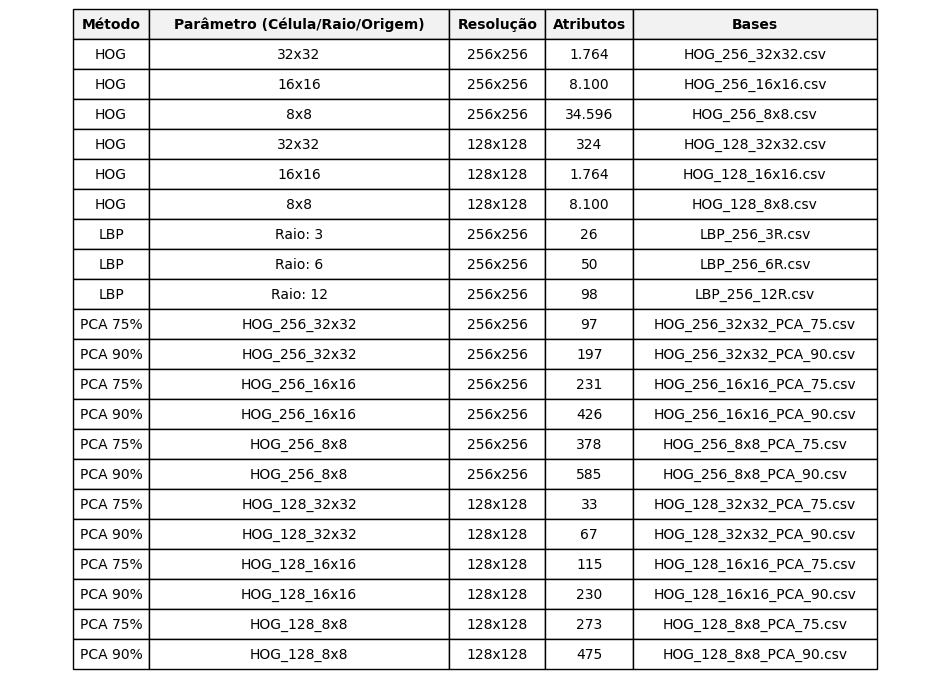

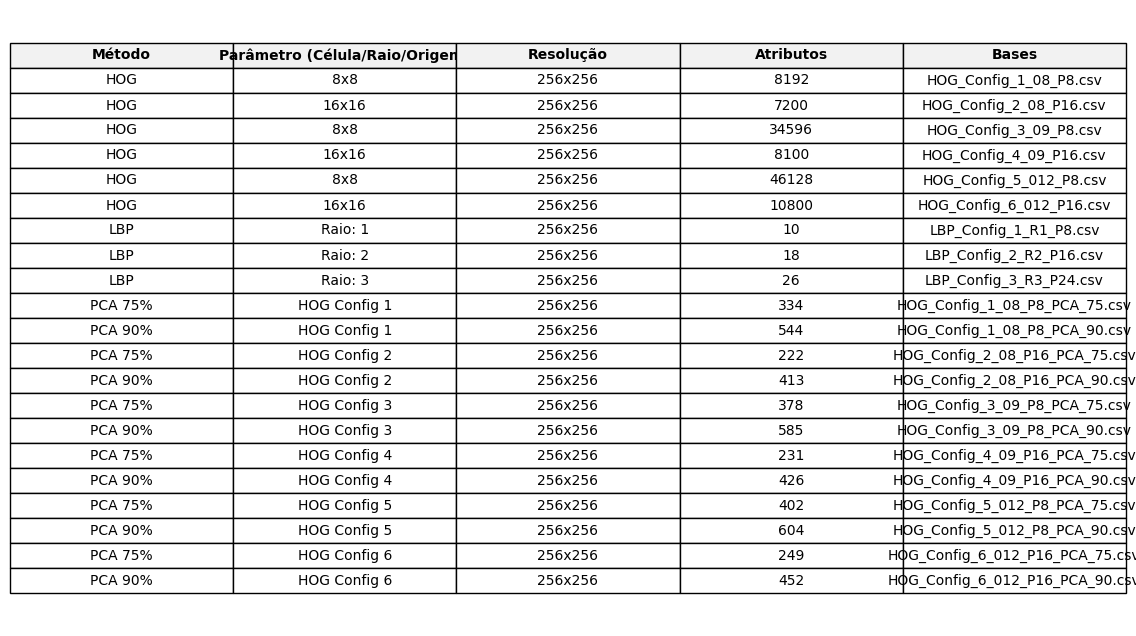

In [ ]:
# **HOG COM PCA**"""

import os
import pandas as pd
from sklearn.decomposition import PCA

print("Etapa 1: A geração de arquivos estáticos de PCA foi desativada.")
print("MOTIVO: Salvar o PCA em CSV antes da validação cruzada causa 'Data Leakage',")
print("pois o PCA 'aprende' padrões da base de teste, inflando o F1 Score artificialmente.")
print("SOLUÇÃO: O PCA agora é aplicado dinamicamente dentro de cada classificador")
print("usando sklearn.pipeline.Pipeline.")

"""# **RELATORIO**"""

import pandas as pd
import matplotlib.pyplot as plt

# 1. Consolidando as informações FINAIS atualizadas com dados do PCA
dados_tabela = [
    # --- BASES HOG ---
    ['HOG', '32x32', '256x256', '1.764', 'HOG_256_32x32.csv'],
    ['HOG', '16x16', '256x256', '8.100', 'HOG_256_16x16.csv'],
    ['HOG', '8x8', '256x256', '34.596', 'HOG_256_8x8.csv'],
    ['HOG', '32x32', '128x128', '324', 'HOG_128_32x32.csv'],
    ['HOG', '16x16', '128x128', '1.764', 'HOG_128_16x16.csv'],
    ['HOG', '8x8', '128x128', '8.100', 'HOG_128_8x8.csv'],

    # --- BASES LBP ---
    ['LBP', 'Raio: 3', '256x256', '26', 'LBP_256_3R.csv'],
    ['LBP', 'Raio: 6', '256x256', '50', 'LBP_256_6R.csv'],
    ['LBP', 'Raio: 12', '256x256', '98', 'LBP_256_12R.csv'],

    # --- BASES PCA ---
    ['PCA 75%', 'HOG_256_32x32', '256x256', '97', 'HOG_256_32x32_PCA_75.csv'],
    ['PCA 90%', 'HOG_256_32x32', '256x256', '197', 'HOG_256_32x32_PCA_90.csv'],
    ['PCA 75%', 'HOG_256_16x16', '256x256', '231', 'HOG_256_16x16_PCA_75.csv'],
    ['PCA 90%', 'HOG_256_16x16', '256x256', '426', 'HOG_256_16x16_PCA_90.csv'],
    ['PCA 75%', 'HOG_256_8x8', '256x256', '378', 'HOG_256_8x8_PCA_75.csv'],
    ['PCA 90%', 'HOG_256_8x8', '256x256', '585', 'HOG_256_8x8_PCA_90.csv'],

    ['PCA 75%', 'HOG_128_32x32', '128x128', '33', 'HOG_128_32x32_PCA_75.csv'],
    ['PCA 90%', 'HOG_128_32x32', '128x128', '67', 'HOG_128_32x32_PCA_90.csv'],
    ['PCA 75%', 'HOG_128_16x16', '128x128', '115', 'HOG_128_16x16_PCA_75.csv'],
    ['PCA 90%', 'HOG_128_16x16', '128x128', '230', 'HOG_128_16x16_PCA_90.csv'],
    ['PCA 75%', 'HOG_128_8x8', '128x128', '273', 'HOG_128_8x8_PCA_75.csv'],
    ['PCA 90%', 'HOG_128_8x8', '128x128', '475', 'HOG_128_8x8_PCA_90.csv']
]

# Criando o DataFrame
colunas = ['Método', 'Parâmetro (Célula/Raio/Origem)', 'Resolução', 'Atributos', 'Bases']
df_descritivo = pd.DataFrame(dados_tabela, columns=colunas)

# Exibindo no Colab
display(df_descritivo)

# Salvando CSV
df_descritivo.to_csv('Tabela_Descritiva_Bases.csv', index=False)
print("\nArquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!")

# 2. Configurar o tamanho e gerar o PDF
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# 3. Criar a tabela visualmente
tabela = ax.table(cellText=df_descritivo.values,
                  colLabels=df_descritivo.columns,
                  loc='center',
                  cellLoc='center')

# 4. Ajustar o estilo e adequar colunas ao texto
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)

# O auto_set_column_width usa o índice das colunas para ajustar a largura ao texto exato
tabela.auto_set_column_width(col=list(range(len(colunas))))

# Aumenta o padding (espaçamento vertical)
tabela.scale(1, 1.8)

# Deixar o cabeçalho em negrito e com fundo cinza claro
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2')

# 5. Salvar o arquivo em formato PDF
plt.savefig('Tabela_Descritiva_Bases.pdf', format='pdf', bbox_inches='tight')
print("✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!")

"""# **Pratica 2**"""

import pandas as pd
import matplotlib.pyplot as plt

# Consolidando as informações do seu relatório no formato da Figura 1
# Colunas baseadas na Figura 1: Método | Pixels por Célula/Radius/Origem | Resolução | Atributos | Bases
dados_tabela = [
    # --- BASES HOG ---
    ['HOG', '8x8', '256x256', 8192, 'HOG_Config_1_08_P8.csv'],
    ['HOG', '16x16', '256x256', 7200, 'HOG_Config_2_08_P16.csv'],
    ['HOG', '8x8', '256x256', 34596, 'HOG_Config_3_09_P8.csv'],
    ['HOG', '16x16', '256x256', 8100, 'HOG_Config_4_09_P16.csv'],
    ['HOG', '8x8', '256x256', 46128, 'HOG_Config_5_012_P8.csv'],
    ['HOG', '16x16', '256x256', 10800, 'HOG_Config_6_012_P16.csv'],

    # --- BASES LBP ---
    ['LBP', 'Raio: 1', '256x256', 10, 'LBP_Config_1_R1_P8.csv'],
    ['LBP', 'Raio: 2', '256x256', 18, 'LBP_Config_2_R2_P16.csv'],
    ['LBP', 'Raio: 3', '256x256', 26, 'LBP_Config_3_R3_P24.csv'],

    # --- BASES PCA ---
    ['PCA 75%', 'HOG Config 1', '256x256', 334, 'HOG_Config_1_08_P8_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 1', '256x256', 544, 'HOG_Config_1_08_P8_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 2', '256x256', 222, 'HOG_Config_2_08_P16_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 2', '256x256', 413, 'HOG_Config_2_08_P16_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 3', '256x256', 378, 'HOG_Config_3_09_P8_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 3', '256x256', 585, 'HOG_Config_3_09_P8_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 4', '256x256', 231, 'HOG_Config_4_09_P16_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 4', '256x256', 426, 'HOG_Config_4_09_P16_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 5', '256x256', 402, 'HOG_Config_5_012_P8_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 5', '256x256', 604, 'HOG_Config_5_012_P8_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 6', '256x256', 249, 'HOG_Config_6_012_P16_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 6', '256x256', 452, 'HOG_Config_6_012_P16_PCA_90.csv']
]

# Criando o DataFrame
colunas = ['Método', 'Parâmetro (Célula/Raio/Origem)', 'Resolução', 'Atributos', 'Bases']
df_descritivo = pd.DataFrame(dados_tabela, columns=colunas)

# Exibindo a tabela de forma bonita no Colab
display(df_descritivo)

# Salvando em um arquivo CSV para você anexar ou converter para PDF
df_descritivo.to_csv('Tabela_Descritiva_Bases.csv', index=False)
print("\nArquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!")

# 1. Carregar o CSV que acabamos de gerar
df = pd.read_csv('Tabela_Descritiva_Bases.csv')

# 2. Configurar o tamanho da "página" do PDF
fig, ax = plt.subplots(figsize=(12, 8)) # Largura x Altura
ax.axis('tight')
ax.axis('off')

# 3. Criar a tabela visualmente
tabela = ax.table(cellText=df.values,
                  colLabels=df.columns,
                  loc='center',
                  cellLoc='center')

# 4. Ajustar o estilo da tabela
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5) # Ajusta a largura e altura das células

# Deixar o cabeçalho em negrito e com fundo cinza
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2')

# 5. Salvar o arquivo em formato PDF
plt.savefig('Tabela_Descritiva_Bases.pdf', format='pdf', bbox_inches='tight')
print("✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!")



# **RELATORIO**

,Método,Parâmetro (Célula/Raio/Origem),Resolução,Atributos,Bases
0,HOG,32x32,256x256,1.764,HOG_256_32x32.csv
1,HOG,16x16,256x256,8.100,HOG_256_16x16.csv
2,HOG,8x8,256x256,34.596,HOG_256_8x8.csv
3,HOG,32x32,128x128,324,HOG_128_32x32.csv
4,HOG,16x16,128x128,1.764,HOG_128_16x16.csv
5,HOG,8x8,128x128,8.100,HOG_128_8x8.csv
6,LBP,Raio: 3,256x256,26,LBP_256_3R.csv
7,LBP,Raio: 6,256x256,50,LBP_256_6R.csv
8,LBP,Raio: 12,256x256,98,LBP_256_12R.csv
9,PCA 75%,HOG_256_32x32,256x256,97,HOG_256_32x32_PCA_75.csv



Arquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!
✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!


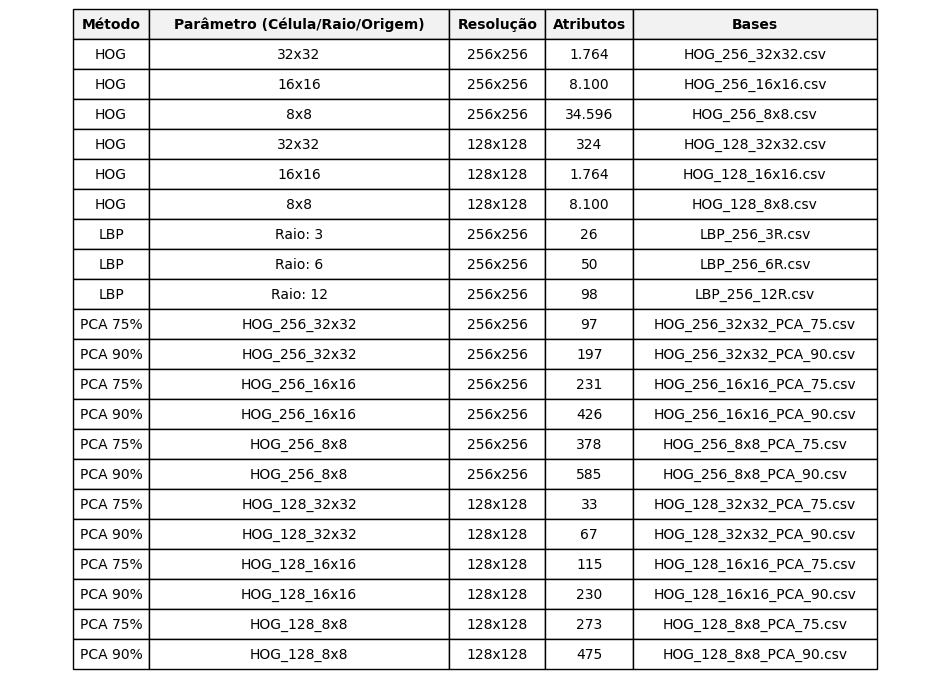

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Consolidando as informações FINAIS atualizadas com dados do PCA
dados_tabela = [
    # --- BASES HOG ---
    ['HOG', '32x32', '256x256', '1.764', 'HOG_256_32x32.csv'],
    ['HOG', '16x16', '256x256', '8.100', 'HOG_256_16x16.csv'],
    ['HOG', '8x8', '256x256', '34.596', 'HOG_256_8x8.csv'],
    ['HOG', '32x32', '128x128', '324', 'HOG_128_32x32.csv'],
    ['HOG', '16x16', '128x128', '1.764', 'HOG_128_16x16.csv'],
    ['HOG', '8x8', '128x128', '8.100', 'HOG_128_8x8.csv'],

    # --- BASES LBP ---
    ['LBP', 'Raio: 3', '256x256', '26', 'LBP_256_3R.csv'],
    ['LBP', 'Raio: 6', '256x256', '50', 'LBP_256_6R.csv'],
    ['LBP', 'Raio: 12', '256x256', '98', 'LBP_256_12R.csv'],

    # --- BASES PCA ---
    ['PCA 75%', 'HOG_256_32x32', '256x256', '97', 'HOG_256_32x32_PCA_75.csv'],
    ['PCA 90%', 'HOG_256_32x32', '256x256', '197', 'HOG_256_32x32_PCA_90.csv'],
    ['PCA 75%', 'HOG_256_16x16', '256x256', '231', 'HOG_256_16x16_PCA_75.csv'],
    ['PCA 90%', 'HOG_256_16x16', '256x256', '426', 'HOG_256_16x16_PCA_90.csv'],
    ['PCA 75%', 'HOG_256_8x8', '256x256', '378', 'HOG_256_8x8_PCA_75.csv'],
    ['PCA 90%', 'HOG_256_8x8', '256x256', '585', 'HOG_256_8x8_PCA_90.csv'],

    ['PCA 75%', 'HOG_128_32x32', '128x128', '33', 'HOG_128_32x32_PCA_75.csv'],
    ['PCA 90%', 'HOG_128_32x32', '128x128', '67', 'HOG_128_32x32_PCA_90.csv'],
    ['PCA 75%', 'HOG_128_16x16', '128x128', '115', 'HOG_128_16x16_PCA_75.csv'],
    ['PCA 90%', 'HOG_128_16x16', '128x128', '230', 'HOG_128_16x16_PCA_90.csv'],
    ['PCA 75%', 'HOG_128_8x8', '128x128', '273', 'HOG_128_8x8_PCA_75.csv'],
    ['PCA 90%', 'HOG_128_8x8', '128x128', '475', 'HOG_128_8x8_PCA_90.csv']
]

# Criando o DataFrame
colunas = ['Método', 'Parâmetro (Célula/Raio/Origem)', 'Resolução', 'Atributos', 'Bases']
df_descritivo = pd.DataFrame(dados_tabela, columns=colunas)

# Exibindo no Colab
display(df_descritivo)

# Salvando CSV
df_descritivo.to_csv('Tabela_Descritiva_Bases.csv', index=False)
print("\nArquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!")

# 2. Configurar o tamanho e gerar o PDF
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# 3. Criar a tabela visualmente
tabela = ax.table(cellText=df_descritivo.values,
                  colLabels=df_descritivo.columns,
                  loc='center',
                  cellLoc='center')

# 4. Ajustar o estilo e adequar colunas ao texto
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)

# O auto_set_column_width usa o índice das colunas para ajustar a largura ao texto exato
tabela.auto_set_column_width(col=list(range(len(colunas))))

# Aumenta o padding (espaçamento vertical)
tabela.scale(1, 1.8)

# Deixar o cabeçalho em negrito e com fundo cinza claro
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2')

# 5. Salvar o arquivo em formato PDF
plt.savefig('Tabela_Descritiva_Bases.pdf', format='pdf', bbox_inches='tight')
print("✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!")

# **Pratica 2**

,Método,Parâmetro (Célula/Raio/Origem),Resolução,Atributos,Bases
0,HOG,8x8,256x256,8192,HOG_Config_1_08_P8.csv
1,HOG,16x16,256x256,7200,HOG_Config_2_08_P16.csv
2,HOG,8x8,256x256,34596,HOG_Config_3_09_P8.csv
3,HOG,16x16,256x256,8100,HOG_Config_4_09_P16.csv
4,HOG,8x8,256x256,46128,HOG_Config_5_012_P8.csv
5,HOG,16x16,256x256,10800,HOG_Config_6_012_P16.csv
6,LBP,Raio: 1,256x256,10,LBP_Config_1_R1_P8.csv
7,LBP,Raio: 2,256x256,18,LBP_Config_2_R2_P16.csv
8,LBP,Raio: 3,256x256,26,LBP_Config_3_R3_P24.csv
9,PCA 75%,HOG Config 1,256x256,334,HOG_Config_1_08_P8_PCA_75.csv



Arquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!
✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!


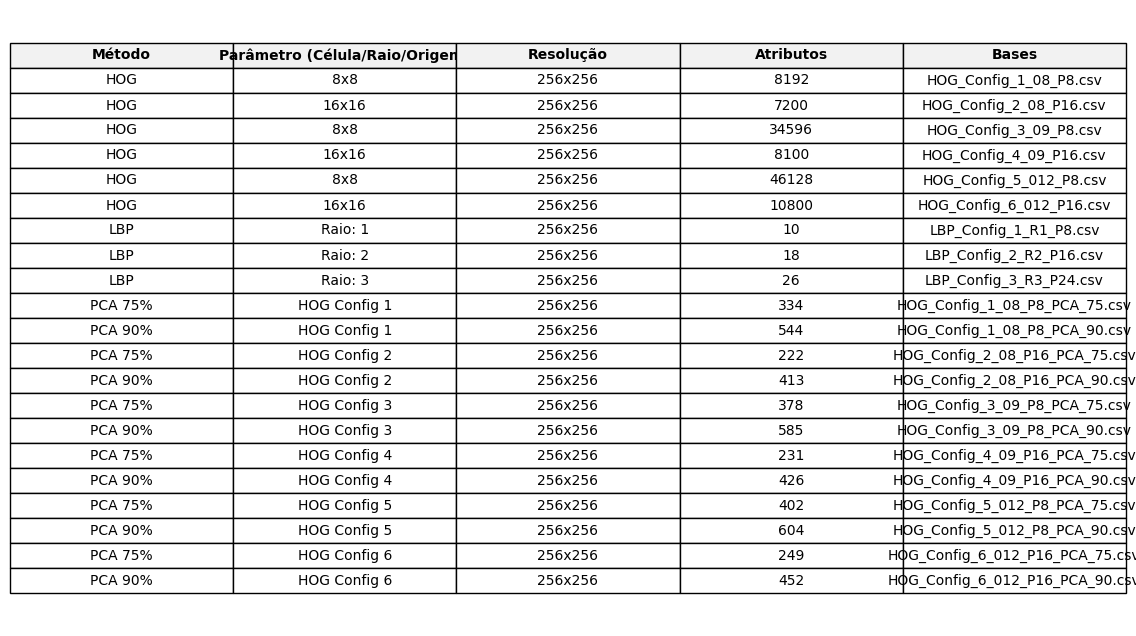

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Consolidando as informações do seu relatório no formato da Figura 1
# Colunas baseadas na Figura 1: Método | Pixels por Célula/Radius/Origem | Resolução | Atributos | Bases
dados_tabela = [
    # --- BASES HOG ---
    ['HOG', '8x8', '256x256', 8192, 'HOG_Config_1_08_P8.csv'],
    ['HOG', '16x16', '256x256', 7200, 'HOG_Config_2_08_P16.csv'],
    ['HOG', '8x8', '256x256', 34596, 'HOG_Config_3_09_P8.csv'],
    ['HOG', '16x16', '256x256', 8100, 'HOG_Config_4_09_P16.csv'],
    ['HOG', '8x8', '256x256', 46128, 'HOG_Config_5_012_P8.csv'],
    ['HOG', '16x16', '256x256', 10800, 'HOG_Config_6_012_P16.csv'],

    # --- BASES LBP ---
    ['LBP', 'Raio: 1', '256x256', 10, 'LBP_Config_1_R1_P8.csv'],
    ['LBP', 'Raio: 2', '256x256', 18, 'LBP_Config_2_R2_P16.csv'],
    ['LBP', 'Raio: 3', '256x256', 26, 'LBP_Config_3_R3_P24.csv'],

    # --- BASES PCA ---
    ['PCA 75%', 'HOG Config 1', '256x256', 334, 'HOG_Config_1_08_P8_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 1', '256x256', 544, 'HOG_Config_1_08_P8_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 2', '256x256', 222, 'HOG_Config_2_08_P16_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 2', '256x256', 413, 'HOG_Config_2_08_P16_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 3', '256x256', 378, 'HOG_Config_3_09_P8_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 3', '256x256', 585, 'HOG_Config_3_09_P8_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 4', '256x256', 231, 'HOG_Config_4_09_P16_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 4', '256x256', 426, 'HOG_Config_4_09_P16_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 5', '256x256', 402, 'HOG_Config_5_012_P8_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 5', '256x256', 604, 'HOG_Config_5_012_P8_PCA_90.csv'],
    ['PCA 75%', 'HOG Config 6', '256x256', 249, 'HOG_Config_6_012_P16_PCA_75.csv'],
    ['PCA 90%', 'HOG Config 6', '256x256', 452, 'HOG_Config_6_012_P16_PCA_90.csv']
]

# Criando o DataFrame
colunas = ['Método', 'Parâmetro (Célula/Raio/Origem)', 'Resolução', 'Atributos', 'Bases']
df_descritivo = pd.DataFrame(dados_tabela, columns=colunas)

# Exibindo a tabela de forma bonita no Colab
display(df_descritivo)

# Salvando em um arquivo CSV para você anexar ou converter para PDF
df_descritivo.to_csv('Tabela_Descritiva_Bases.csv', index=False)
print("\nArquivo 'Tabela_Descritiva_Bases.csv' gerado com sucesso!")

# 1. Carregar o CSV que acabamos de gerar
df = pd.read_csv('Tabela_Descritiva_Bases.csv')

# 2. Configurar o tamanho da "página" do PDF
fig, ax = plt.subplots(figsize=(12, 8)) # Largura x Altura
ax.axis('tight')
ax.axis('off')

# 3. Criar a tabela visualmente
tabela = ax.table(cellText=df.values,
                  colLabels=df.columns,
                  loc='center',
                  cellLoc='center')

# 4. Ajustar o estilo da tabela
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.5) # Ajusta a largura e altura das células

# Deixar o cabeçalho em negrito e com fundo cinza
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#f2f2f2')

# 5. Salvar o arquivo em formato PDF
plt.savefig('Tabela_Descritiva_Bases.pdf', format='pdf', bbox_inches='tight')
print("✅ Arquivo 'Tabela_Descritiva_Bases.pdf' gerado com sucesso!")


# **K-nn**

✅ Processado: HOG_256_32x32.csv
✅ Processado: HOG_256_16x16.csv
✅ Processado: HOG_256_8x8.csv
✅ Processado: HOG_128_32x32.csv
✅ Processado: HOG_128_16x16.csv
✅ Processado: HOG_128_8x8.csv
✅ Processado: HOG_256_32x32_PCA_75.csv
✅ Processado: HOG_256_32x32_PCA_90.csv
✅ Processado: HOG_256_16x16_PCA_75.csv
✅ Processado: HOG_256_16x16_PCA_90.csv
✅ Processado: HOG_256_8x8_PCA_75.csv
✅ Processado: HOG_256_8x8_PCA_90.csv
✅ Processado: HOG_128_32x32_PCA_75.csv
✅ Processado: HOG_128_32x32_PCA_90.csv
✅ Processado: HOG_128_16x16_PCA_75.csv
✅ Processado: HOG_128_16x16_PCA_90.csv
✅ Processado: HOG_128_8x8_PCA_75.csv
✅ Processado: HOG_128_8x8_PCA_90.csv
✅ Processado: LBP_256_3R.csv
✅ Processado: LBP_256_6R.csv
✅ Processado: LBP_256_12R.csv

✅ Arquivo 'Resultados_kNN_Final_Euclidean.csv' salvo com sucesso com as médias e desvios no final!
Gerando o PDF das 12 melhores bases...
✅ Sucesso! O arquivo 'Top_12_Melhores_Bases_kNN.pdf' foi gerado e está pronto para ser enviado no SIGAA.
Gerando o PDF das 12

FileNotFoundError: Cannot find file: /content/aprendizadoDeMaquina.zip

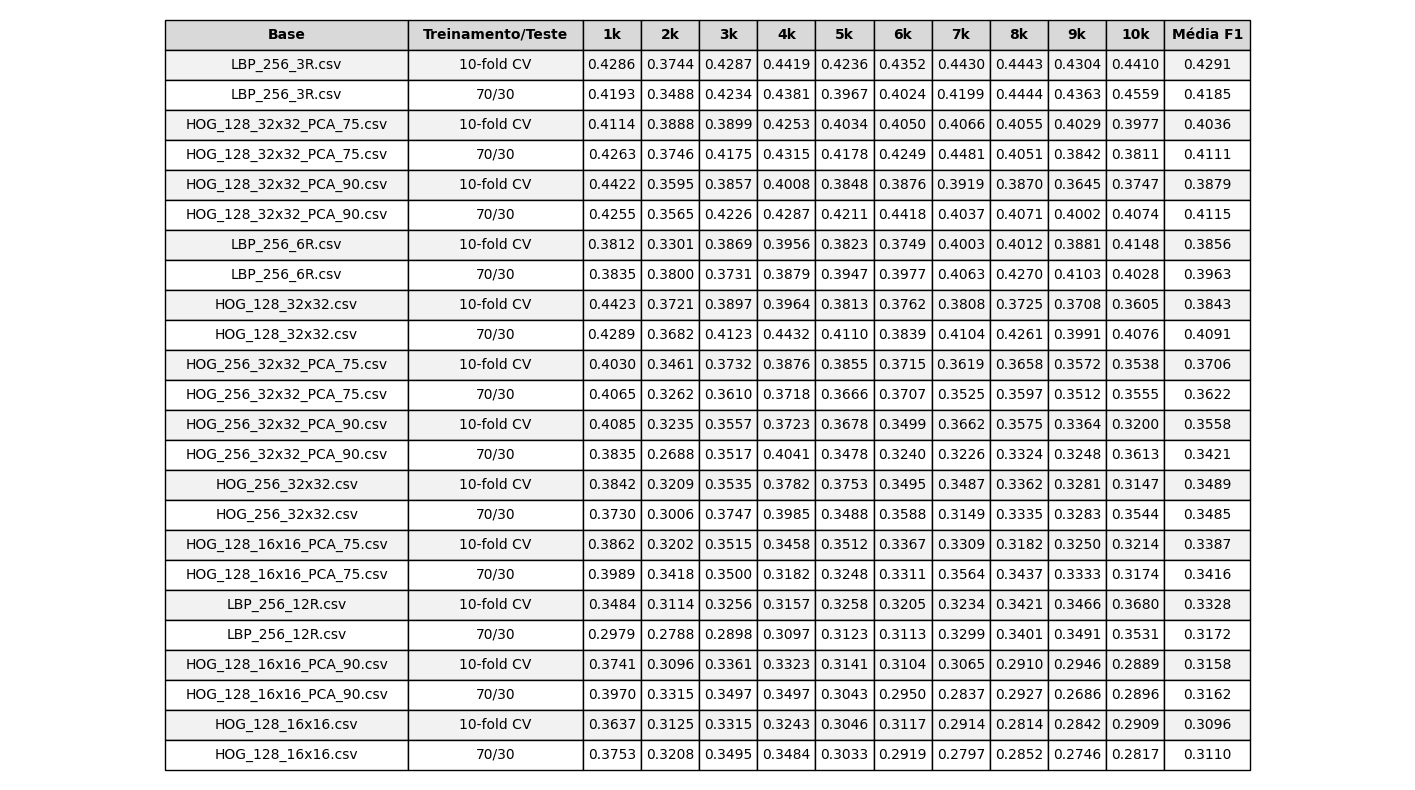

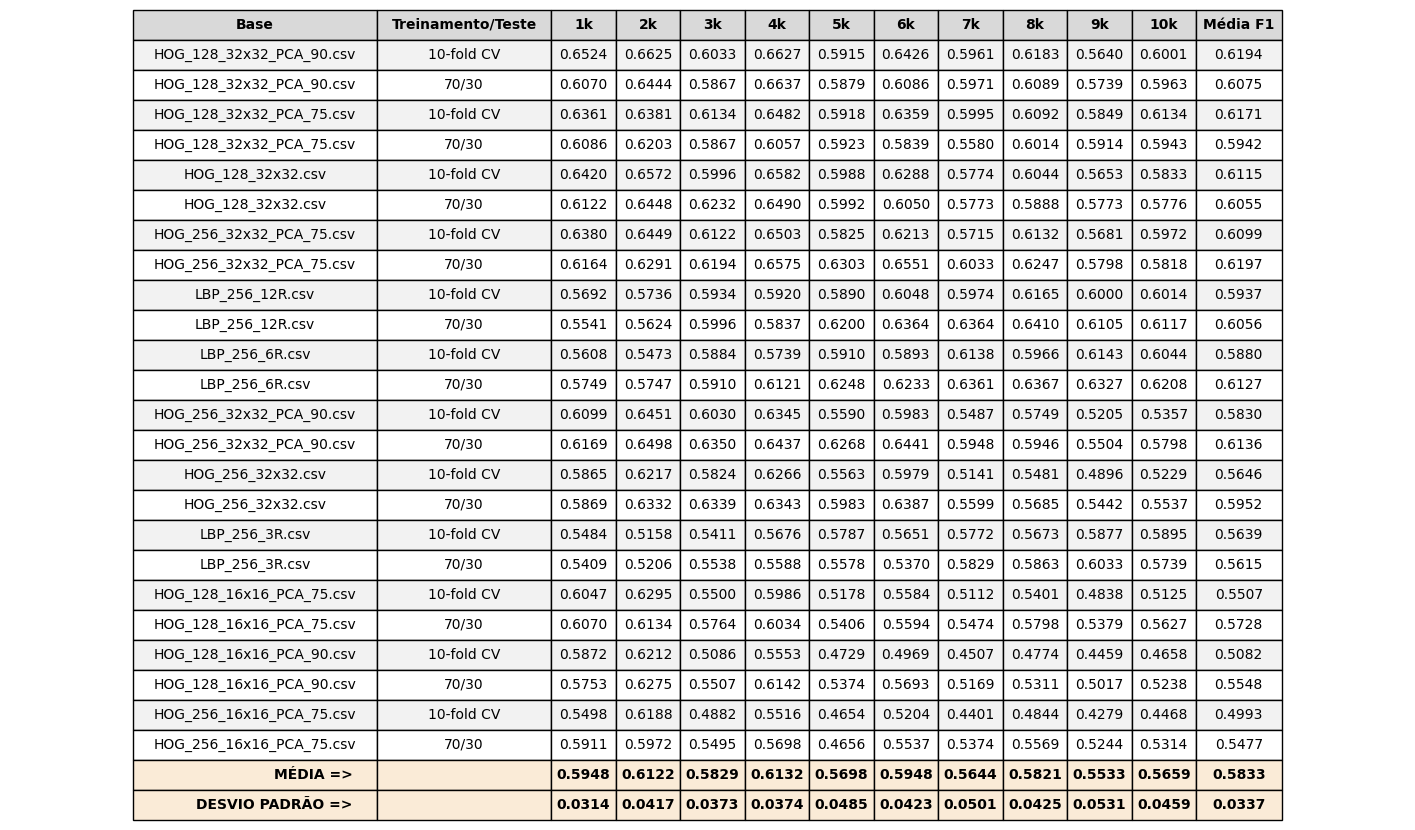

In [ ]:
"""# **K-nn**"""

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import warnings

# Ignorar warnings de F1-score para classes sem predição
warnings.filterwarnings('ignore')

# Lista exata das bases
bases_csv = [
    # --- BASES HOG ---
    "HOG_256_32x32.csv", "HOG_256_16x16.csv", "HOG_256_8x8.csv",
    "HOG_128_32x32.csv", "HOG_128_16x16.csv", "HOG_128_8x8.csv",
    # --- BASES PCA (HOG) ---
    "HOG_256_32x32_PCA_75.csv", "HOG_256_32x32_PCA_90.csv",
    "HOG_256_16x16_PCA_75.csv", "HOG_256_16x16_PCA_90.csv",
    "HOG_256_8x8_PCA_75.csv", "HOG_256_8x8_PCA_90.csv",
    "HOG_128_32x32_PCA_75.csv", "HOG_128_32x32_PCA_90.csv",
    "HOG_128_16x16_PCA_75.csv", "HOG_128_16x16_PCA_90.csv",
    "HOG_128_8x8_PCA_75.csv", "HOG_128_8x8_PCA_90.csv",
    # --- BASES LBP ---
    "LBP_256_3R.csv", "LBP_256_6R.csv", "LBP_256_12R.csv"
]

resultados = []

for base in bases_csv:
    try:
        arquivo_leitura = base
        usar_pca = False
        n_comp_pca = None
        if "_PCA_" in base:
            usar_pca = True
            partes = base.replace('.csv', '').split('_PCA_')
            arquivo_leitura = partes[0] + '.csv'
            n_comp_pca = int(partes[1]) / 100.0

        df = pd.read_csv(arquivo_leitura)
        X = df.iloc[:, :-1].values
        y_texto = df.iloc[:, -1].values

        # Converte as classes para números (Exigência do kNN)
        le = LabelEncoder()
        y = le.fit_transform(y_texto)

        # Preparar o Holdout (70/30)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

        # Prepara as linhas da tabela para esta base
        linha_cv = {'Base': base, 'Treinamento/Teste': '10-fold CV'}
        linha_holdout = {'Base': base, 'Treinamento/Teste': '70/30'}

        # Varia o parâmetro k de 1 a 10 mantendo 'euclidean'
        for k in range(1, 11):
            if usar_pca:
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('pca', PCA(n_components=n_comp_pca, random_state=42)),
                    ('knn', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
                ])
            else:
                pipeline = Pipeline([
                    ('scaler', StandardScaler()),
                    ('knn', KNeighborsClassifier(n_neighbors=k, metric='euclidean'))
                ])

            # Avaliação 1: 10-fold Cross-Validation
            scores_cv = cross_val_score(pipeline, X, y, cv=10, scoring='f1_macro')
            linha_cv[f'{k}k'] = np.mean(scores_cv)

            # Avaliação 2: Holdout 70/30
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            linha_holdout[f'{k}k'] = f1_score(y_test, y_pred, average='macro')

        resultados.append(linha_cv)
        resultados.append(linha_holdout)
        print(f"✅ Processado: {base}")

    except FileNotFoundError:
        print(f"❌ Arquivo não encontrado: {base}")

# Montar o DataFrame principal
df_resultados = pd.DataFrame(resultados)

# --- CÁLCULO FINAL DE MÉDIA E DESVIO PADRÃO PARA CADA k ---
colunas_k = [f'{i}k' for i in range(1, 11)]

# Calcula média e desvio apenas das colunas numéricas de 1k a 10k
medias = df_resultados[colunas_k].mean().to_dict()
desvios = df_resultados[colunas_k].std().to_dict()

# Adiciona os rótulos para as duas linhas finais
medias['Base'] = 'MÉDIA'
medias['Treinamento/Teste'] = '-'
desvios['Base'] = 'DESVIO PADRÃO'
desvios['Treinamento/Teste'] = '-'

# Adiciona as linhas matemáticas no final da tabela
df_final = pd.concat([df_resultados, pd.DataFrame([medias, desvios])], ignore_index=True)

# Salvar a tabela final exigida pela disciplina
df_final.to_csv('Resultados_kNN_Final_Euclidean.csv', index=False)
print("\n✅ Arquivo 'Resultados_kNN_Final_Euclidean.csv' salvo com sucesso com as médias e desvios no final!")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregar os resultados completos gerados no passo anterior
df_completo = pd.read_csv('Resultados_kNN_Final_Euclidean.csv')

# Remover as linhas de "MÉDIA" e "DESVIO PADRÃO" do final para não atrapalhar o ranqueamento
df_dados = df_completo[~df_completo['Base'].isin(['MÉDIA', 'DESVIO PADRÃO'])].copy()

# Colunas de k
colunas_k = [f'{i}k' for i in range(1, 11)]

# Calcular a média geral de cada linha para o ranqueamento
df_dados['Media_Geral'] = df_dados[colunas_k].mean(axis=1)

# 2. Descobrir as 12 melhores bases (usando o 10-fold CV como critério de desempate/ranking)
df_cv = df_dados[df_dados['Treinamento/Teste'] == '10-fold CV']
top_12_bases = df_cv.sort_values(by='Media_Geral', ascending=False).head(12)['Base'].tolist()

# 3. Filtrar o DataFrame original para trazer as linhas das Top 12 (Trazendo o 10-fold e o 70/30)
# Usamos o Categorical para garantir que a ordem do ranking (da melhor pra pior) seja mantida na tabela
df_top12 = df_dados[df_dados['Base'].isin(top_12_bases)].copy()
df_top12['Base'] = pd.Categorical(df_top12['Base'], categories=top_12_bases, ordered=True)
df_top12 = df_top12.sort_values(by=['Base', 'Treinamento/Teste'])

# 4. Formatar a tabela para o PDF ficar limpo e igual à sua imagem
# Arredondar os valores para 3 ou 4 casas decimais para não poluir visualmente
for col in colunas_k + ['Media_Geral']:
    df_top12[col] = df_top12[col].apply(lambda x: f"{x:.4f}")

# Renomear colunas para o PDF
df_top12.rename(columns={'Media_Geral': 'Média F1'}, inplace=True)

# 5. Gerar o PDF com Matplotlib
print("Gerando o PDF das 12 melhores bases...")

fig, ax = plt.subplots(figsize=(18, 10)) # Tamanho largo para caber todas as colunas
ax.axis('tight')
ax.axis('off')

# Criar a tabela
tabela = ax.table(cellText=df_top12.values,
                  colLabels=df_top12.columns,
                  loc='center',
                  cellLoc='center')

# Estilizar a tabela (Fonte, altura das células, cabeçalho)
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8) # Estica um pouco para não ficar espremido

# Colorir o cabeçalho de cinza e colocar em negrito
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    else:
        # Pinta levemente as linhas do '10-fold CV' para destacar os blocos (opcional, igual sua imagem)
        if df_top12.iloc[row-1]['Treinamento/Teste'] == '10-fold CV':
            cell.set_facecolor('#f2f2f2')

# Ajustar a largura da primeira coluna (Nome da Base) que costuma ser maior
tabela.auto_set_column_width(col=list(range(len(df_top12.columns))))

# Salvar como PDF pronto para o SIGAA
nome_arquivo_pdf = 'Top_12_Melhores_Bases_kNN.pdf'
plt.savefig(nome_arquivo_pdf, format='pdf', bbox_inches='tight')

print(f"✅ Sucesso! O arquivo '{nome_arquivo_pdf}' foi gerado e está pronto para ser enviado no SIGAA.")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_knn = os.path.join(caminho_drive, 'Resultados_kNN_Final_Euclidean.csv')
# 1. Carregar os resultados completos gerados no passo anterior
df_completo = pd.read_csv(caminho_knn)

# Remover as linhas de "MÉDIA" e "DESVIO PADRÃO" do final para não atrapalhar o ranqueamento
df_dados = df_completo[~df_completo['Base'].isin(['MÉDIA', 'DESVIO PADRÃO', 'MÉDIA =>', 'DESVIO PADRÃO =>'])].copy()

# Colunas de k
colunas_k = [f'{i}k' for i in range(1, 11)]

# Calcular a média geral de cada linha para o ranqueamento
df_dados['Media_Geral'] = df_dados[colunas_k].mean(axis=1)

# 2. Descobrir as 12 melhores bases (usando o 10-fold CV como critério de desempate/ranking)
df_cv = df_dados[df_dados['Treinamento/Teste'] == '10-fold CV']
top_12_bases = df_cv.sort_values(by='Media_Geral', ascending=False).head(12)['Base'].tolist()

# 3. Filtrar o DataFrame original para trazer as linhas das Top 12 (Trazendo o 10-fold e o 70/30)
df_top12 = df_dados[df_dados['Base'].isin(top_12_bases)].copy()
df_top12['Base'] = pd.Categorical(df_top12['Base'], categories=top_12_bases, ordered=True)
df_top12 = df_top12.sort_values(by=['Base', 'Treinamento/Teste'])

# Converter a coluna 'Base' de volta para string para podermos adicionar as linhas de Média e Desvio
df_top12['Base'] = df_top12['Base'].astype(str)

# --- NOVO: Cálculo de Média e Desvio Padrão das colunas numéricas ---
colunas_numericas = colunas_k + ['Media_Geral']

linha_media = {col: df_top12[col].mean() for col in colunas_numericas}
linha_media['Base'] = 'MÉDIA =>'
linha_media['Treinamento/Teste'] = ''

linha_desvio = {col: df_top12[col].std() for col in colunas_numericas}
linha_desvio['Base'] = 'DESVIO PADRÃO =>'
linha_desvio['Treinamento/Teste'] = ''

# Adicionando as linhas ao final do DataFrame
df_top12 = pd.concat([df_top12, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)
# --------------------------------------------------------------------

# 4. Formatar a tabela para o PDF ficar limpo
# Arredondar os valores numéricos para 4 casas decimais
for col in colunas_numericas:
    df_top12[col] = df_top12[col].apply(lambda x: f"{float(x):.4f}" if pd.notnull(x) else "")

# Renomear colunas para o PDF
df_top12.rename(columns={'Media_Geral': 'Média F1'}, inplace=True)

# Preencher possíveis valores NaN com string vazia
df_top12.fillna('', inplace=True)

# 5. Gerar o PDF com Matplotlib
print("Gerando o PDF das 12 melhores bases...")

fig, ax = plt.subplots(figsize=(18, 10)) # Tamanho largo para caber todas as colunas
ax.axis('tight')
ax.axis('off')

# Criar a tabela
tabela = ax.table(cellText=df_top12.values,
                  colLabels=df_top12.columns,
                  loc='center',
                  cellLoc='center')

# Estilizar a tabela
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1.2, 1.8) # Estica um pouco para não ficar espremido

total_linhas = len(df_top12)

# Colorir e formatar as células
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        # Cabeçalho
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > total_linhas - 2:
        # Últimas duas linhas (Média e Desvio Padrão)
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#faebd7')
        if col == 0: # Alinha os rótulos à direita
            cell.set_text_props(ha='right')
    else:
        # Linhas normais (pinta levemente as linhas do '10-fold CV')
        if df_top12.iloc[row-1]['Treinamento/Teste'] == '10-fold CV':
            cell.set_facecolor('#f2f2f2')

# Ajustar a largura das colunas
tabela.auto_set_column_width(col=list(range(len(df_top12.columns))))

# Salvar como PDF pronto para o SIGAA
nome_arquivo_pdf = 'Top_12_Melhores_Bases_kNN.pdf'
plt.savefig(nome_arquivo_pdf, format='pdf', bbox_inches='tight')

print(f"✅ Sucesso! O arquivo '{nome_arquivo_pdf}' foi gerado e está pronto para ser enviado no SIGAA.")

from google.colab import files

# Nome do arquivo que será gerado
aprendizadoDeMaquina = "/content/aprendizadoDeMaquina.zip"

print("Compactando os arquivos...")
# Comando de terminal para zipar tudo, excluindo a pasta sample_data e o próprio zip
!zip -r aprendizadoDeMaquina /content/* -x "*/sample_data/*" -x "*/images/*" -x "{aprendizadoDeMaquina}" -x "{images.tar.gz}"

print("\nIniciando o download...")
# Aciona o download automático no seu navegador
files.download(aprendizadoDeMaquina)

"""# **Arvores**"""


# **Arvores**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== FASE 1: GRID SEARCH NA MELHOR BASE ===
Melhor base detectada: HOG_128_32x32_PCA_90.csv

=== FASE 2: EXPERIMENTOS NAS 12 BASES (TOP 10 CONFIGS) ===
✅ Processada: HOG_128_32x32_PCA_90.csv
✅ Processada: HOG_128_32x32_PCA_75.csv
✅ Processada: HOG_128_32x32.csv
✅ Processada: HOG_256_32x32_PCA_75.csv
✅ Processada: LBP_256_12R.csv
✅ Processada: LBP_256_6R.csv
✅ Processada: HOG_256_32x32_PCA_90.csv
✅ Processada: HOG_256_32x32.csv
✅ Processada: LBP_256_3R.csv
✅ Processada: HOG_128_16x16_PCA_75.csv
✅ Processada: HOG_128_16x16_PCA_90.csv
✅ Processada: HOG_256_16x16_PCA_75.csv

✅ PROCESSO CONCLUÍDO!
Os arquivos foram salvos com segurança no seu Drive em: /content/drive/My Drive/aprendizadoDeMaquina/content/
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dados carregados com sucesso!

✅ 

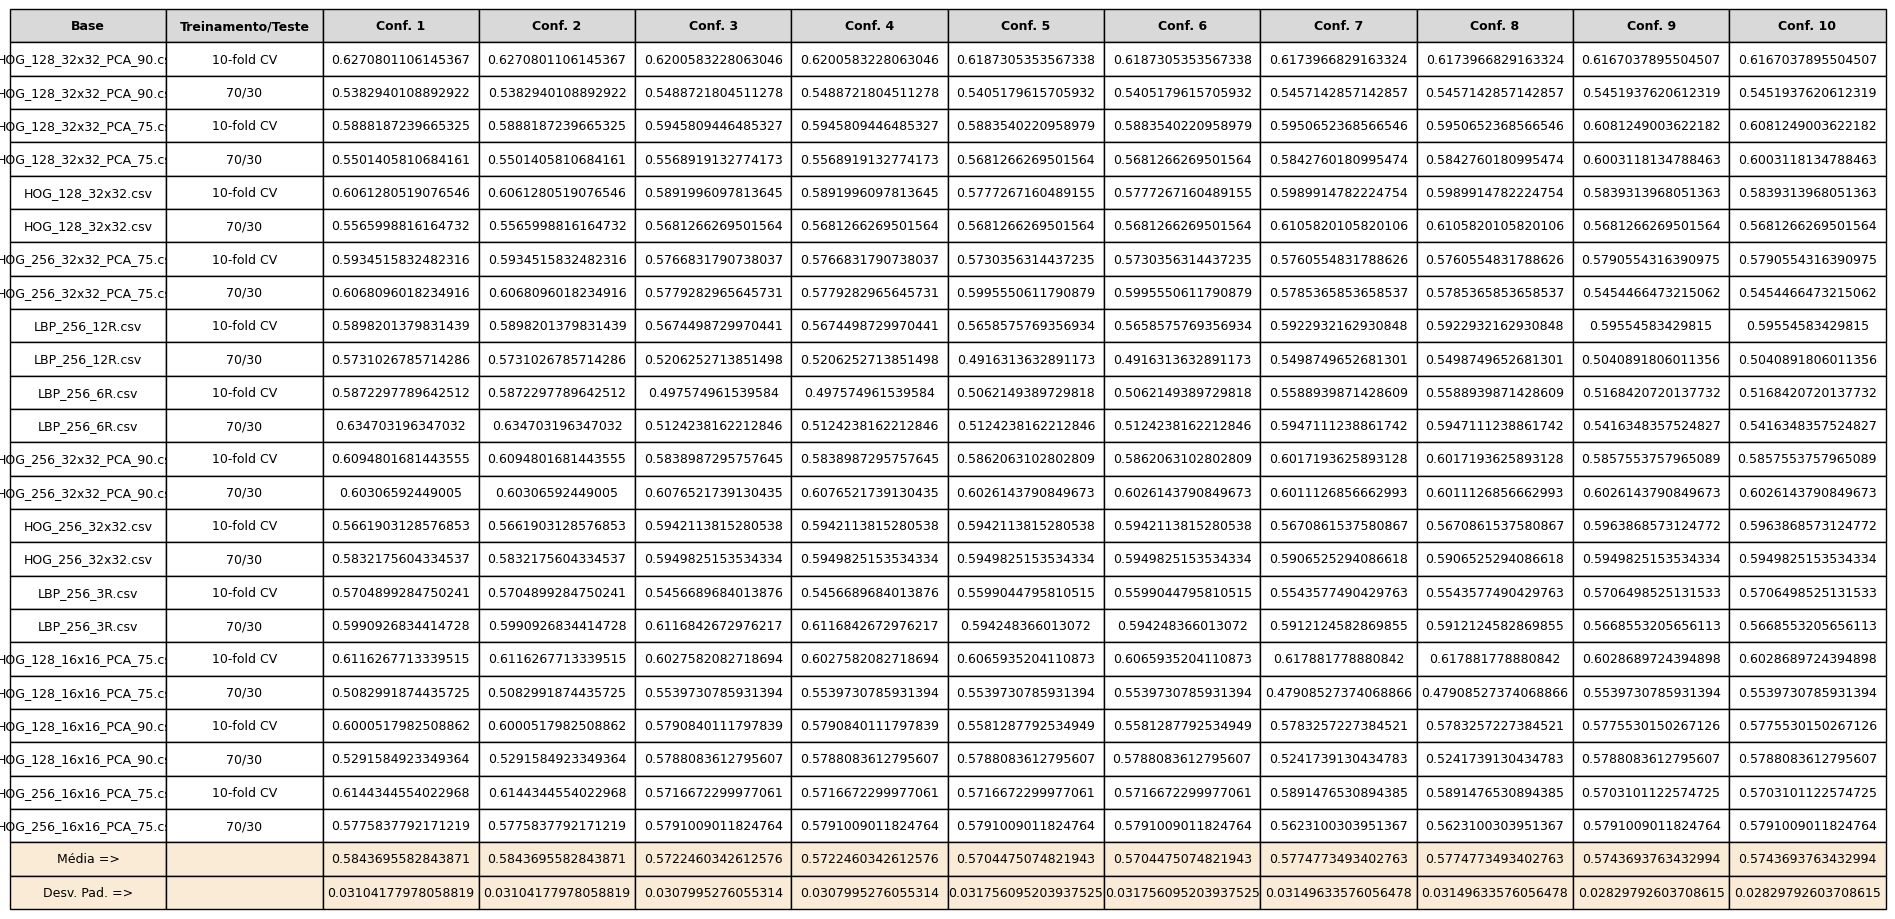

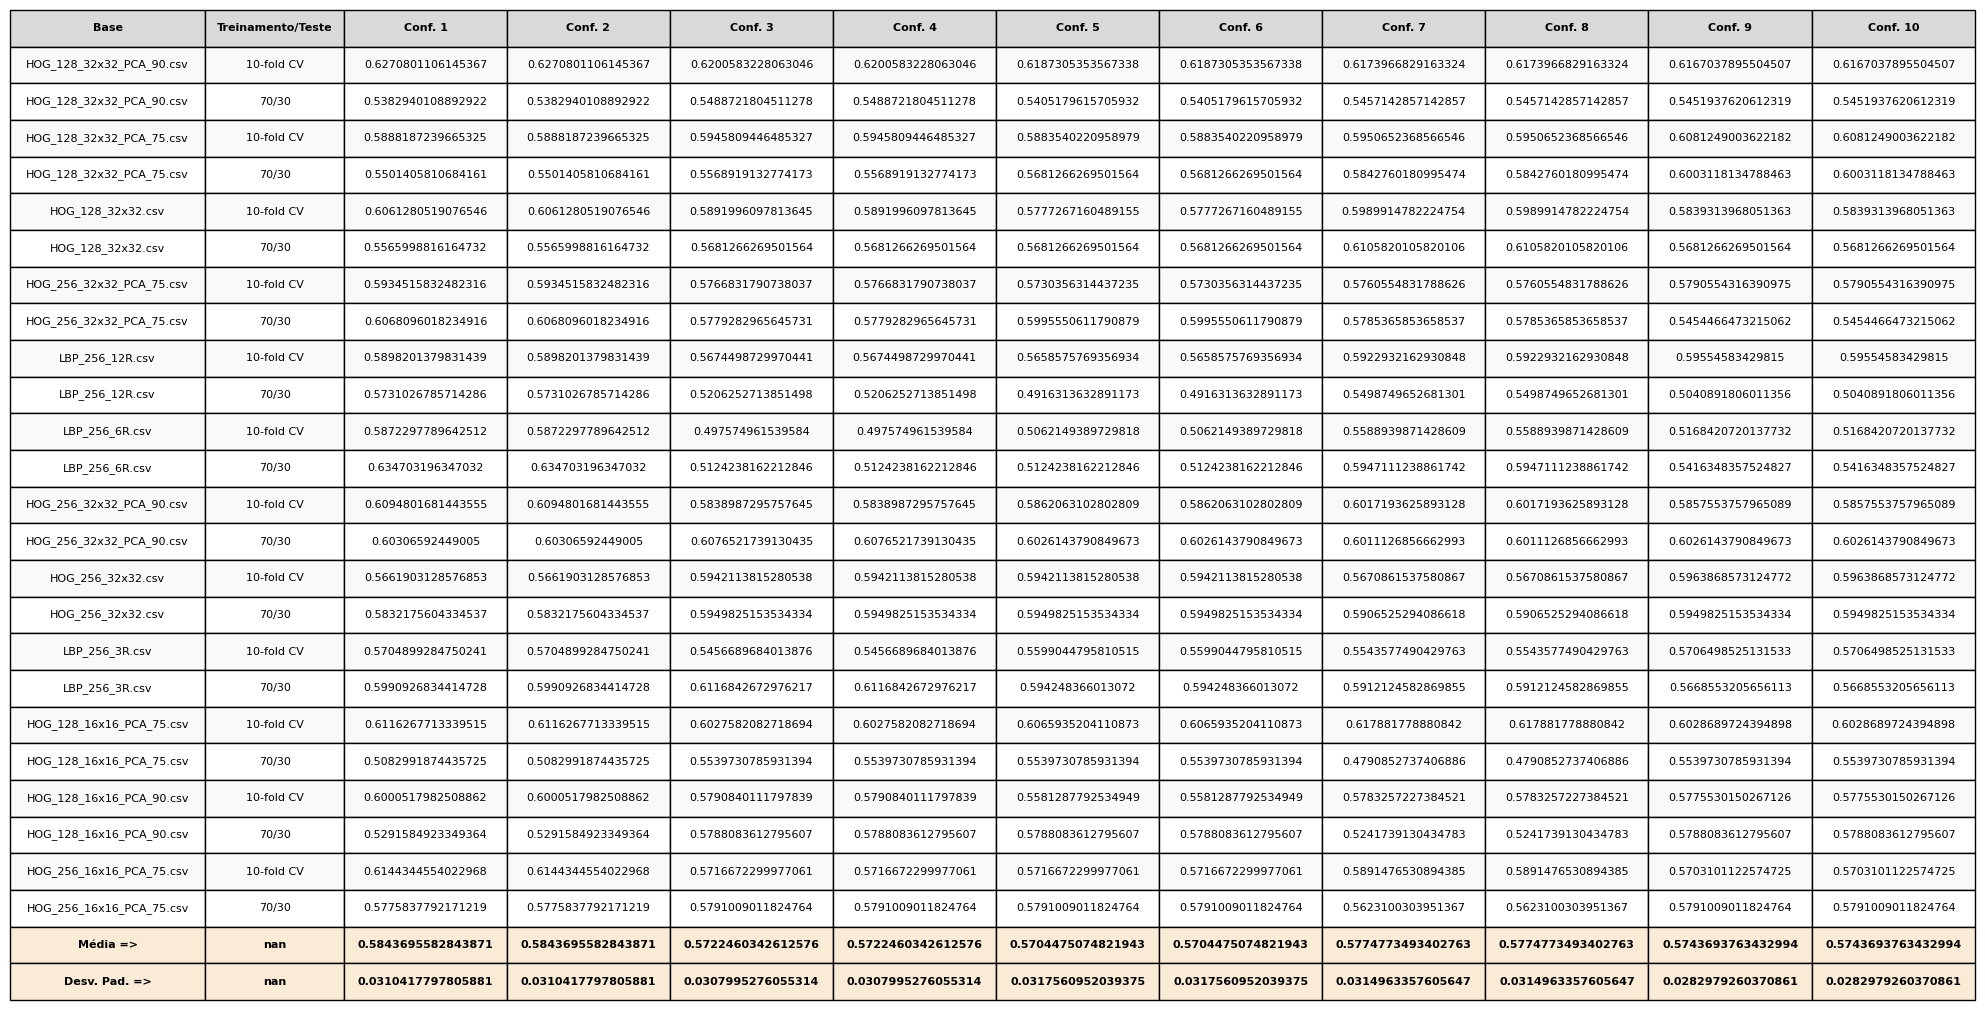

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive
import warnings

warnings.filterwarnings('ignore')

# 1. Montar o Google Drive
drive.mount('/content/drive')

# 2. Definir o caminho da sua pasta no Drive
# O Colab monta o "My Drive" dentro de "/content/drive/"
caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'

print("=== FASE 1: GRID SEARCH NA MELHOR BASE ===")

# Carregar o ranking do k-NN salvo no seu Drive
caminho_ranking = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')

try:
    df_top_bases = pd.read_csv(caminho_ranking)
    bases_selecionadas = df_top_bases['Base'].unique().tolist()
    melhor_base_absoluta = bases_selecionadas[0] # A melhor base segundo o k-NN [cite: 11]
    print(f"Melhor base detectada: {melhor_base_absoluta}")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em {caminho_ranking}")
    exit()

# Parâmetros para o GridSearch (Figura 1) [cite: 7, 10]
par_criterion = ['gini', 'entropy', 'log_loss']
par_max_depth = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Carregar dados da melhor base do Drive (Interceptando PCA)
arquivo_leitura_best = melhor_base_absoluta
usar_pca_best = False
n_comp_pca_best = None
if "_PCA_" in melhor_base_absoluta:
    usar_pca_best = True
    partes = melhor_base_absoluta.replace('.csv', '').split('_PCA_')
    arquivo_leitura_best = partes[0] + '.csv'
    n_comp_pca_best = int(partes[1]) / 100.0

df_best = pd.read_csv(os.path.join(caminho_drive, arquivo_leitura_best))
X_best = df_best.iloc[:, :-1].values
y_best = LabelEncoder().fit_transform(df_best.iloc[:, -1].values)

resultados_grid = []

# Executar o GridSearch (42 combinações) [cite: 13]
for c in par_criterion:
    for d in par_max_depth:
        if usar_pca_best:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp_pca_best, random_state=42)),
                ('dt', DecisionTreeClassifier(criterion=c, max_depth=d, random_state=42))
            ])
        else:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('dt', DecisionTreeClassifier(criterion=c, max_depth=d, random_state=42))
            ])
        scores_cv = cross_val_score(pipeline, X_best, y_best, cv=10, scoring='f1_macro')
        resultados_grid.append({
            'criterion': c,
            'max_depth': d,
            'f1_score': np.mean(scores_cv)
        })

# Selecionar as 10 melhores configurações (Figura 3) [cite: 112, 134]
df_grid = pd.DataFrame(resultados_grid)
top_10_configs = df_grid.sort_values(by='f1_score', ascending=False).head(10).to_dict('records')

print("\n=== FASE 2: EXPERIMENTOS NAS 12 BASES (TOP 10 CONFIGS) ===")

resultados_finais = []
le = LabelEncoder()

for base in bases_selecionadas:
    # Interceptar PCA na base atual
    arquivo_leitura = base
    usar_pca = False
    n_comp_pca = None
    if "_PCA_" in base:
        usar_pca = True
        partes = base.replace('.csv', '').split('_PCA_')
        arquivo_leitura = partes[0] + '.csv'
        n_comp_pca = int(partes[1]) / 100.0

    # Carregar base do Drive
    df = pd.read_csv(os.path.join(caminho_drive, arquivo_leitura))
    X = df.iloc[:, :-1].values
    y = le.fit_transform(df.iloc[:, -1].values)

    # Split Holdout 70/30 [cite: 113]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

    linha_cv = {'Base': base, 'Treinamento/Teste': '10-fold CV'}
    linha_holdout = {'Base': base, 'Treinamento/Teste': '70/30'}

    for i, config in enumerate(top_10_configs, 1):
        if usar_pca:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp_pca, random_state=42)),
                ('dt', DecisionTreeClassifier(criterion=config['criterion'], max_depth=config['max_depth'], random_state=42))
            ])
        else:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('dt', DecisionTreeClassifier(criterion=config['criterion'], max_depth=config['max_depth'], random_state=42))
            ])

        # 10-fold CV [cite: 12]
        scores_cv = cross_val_score(pipeline, X, y, cv=10, scoring='f1_macro')
        linha_cv[f'Conf. {i}'] = np.mean(scores_cv)

        # Holdout 70/30 [cite: 113]
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        linha_holdout[f'Conf. {i}'] = f1_score(y_test, y_pred, average='macro')

    resultados_finais.append(linha_cv)
    resultados_finais.append(linha_holdout)
    print(f"✅ Processada: {base}")

# 3. Gerar a planilha final com Médias e Desvios
df_resultados = pd.DataFrame(resultados_finais)
colunas_conf = [f'Conf. {i}' for i in range(1, 11)]

medias = df_resultados[colunas_conf].mean().to_dict()
desvios = df_resultados[colunas_conf].std().to_dict()

medias.update({'Base': 'Média =>', 'Treinamento/Teste': ''})
desvios.update({'Base': 'Desv. Pad. =>', 'Treinamento/Teste': ''})

df_final = pd.concat([df_resultados, pd.DataFrame([medias, desvios])], ignore_index=True)

# Salvar o CSV de volta no Drive para não perder nada
caminho_csv_final = os.path.join(caminho_drive, 'Resultados_DT_Planilha.csv')
df_final.to_csv(caminho_csv_final, index=False)

# 4. Gerar o PDF (Figura 4)
fig, ax = plt.subplots(figsize=(22, 10))
ax.axis('tight')
ax.axis('off')

tabela = ax.table(cellText=df_final.values, colLabels=df_final.columns, loc='center', cellLoc='center')
tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.scale(1.1, 2)

# Estilização básica
for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > len(df_resultados):
        cell.set_facecolor('#faebd7')

# Salvar PDF no Drive
caminho_pdf_final = os.path.join(caminho_drive, 'Resultados_DecisionTree_SIGAA.pdf')
plt.savefig(caminho_pdf_final, format='pdf', bbox_inches='tight')

print(f"\n✅ PROCESSO CONCLUÍDO!")
print(f"Os arquivos foram salvos com segurança no seu Drive em: {caminho_drive}")

import os
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# 1. Montar o Drive (caso tenha reiniciado a sessão)
drive.mount('/content/drive')

# 2. Caminhos dos arquivos
caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_csv = os.path.join(caminho_drive, 'Resultados_DT_Planilha.csv')
caminho_pdf_v2 = os.path.join(caminho_drive, 'Resultados_DecisionTree_SIGAA_v2.pdf')

# 3. Carregar os dados salvos anteriormente
if os.path.exists(caminho_csv):
    df_final = pd.read_csv(caminho_csv)
    print("Dados carregados com sucesso!")
else:
    print(f"Erro: O arquivo {caminho_csv} não foi encontrado.")
    exit()

# 4. Gerar o PDF com ajuste dinâmico de largura
# Aumentamos a largura da figura (figsize) para dar mais "respiro" às colunas
fig, ax = plt.subplots(figsize=(24, 12))
ax.axis('tight')
ax.axis('off')

# Criar a tabela
tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

# Configurações de estilo
tabela.auto_set_font_size(False)
tabela.set_fontsize(8) # Fonte levemente menor para ajudar no encaixe

# AJUSTE AUTOMÁTICO: Esta função calcula a largura ideal baseada no conteúdo de cada coluna
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))

# Escalonamento: Ajusta a altura das células (2.2) para que o texto não encoste nas bordas
tabela.scale(1, 2.2)

# Cores e Negrito (mantendo o padrão da aula)
for (row, col), cell in tabela.get_celld().items():
    # Cabeçalho
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    # Linhas de Média e Desvio (últimas duas linhas)
    elif row > (len(df_final) - 2):
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
    # Linhas de dados normais (alternando cor para leitura)
    else:
        if row % 2 == 0:
            cell.set_facecolor('#ffffff')
        else:
            cell.set_facecolor('#f9f9f9')

# Salvar a nova versão do PDF
plt.savefig(caminho_pdf_v2, format='pdf', bbox_inches='tight', dpi=300)

print(f"\n✅ PDF atualizado gerado: 'Resultados_DecisionTree_SIGAA_v2.pdf'")
print(f"O arquivo foi salvo na sua pasta do Drive.")


# NB

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


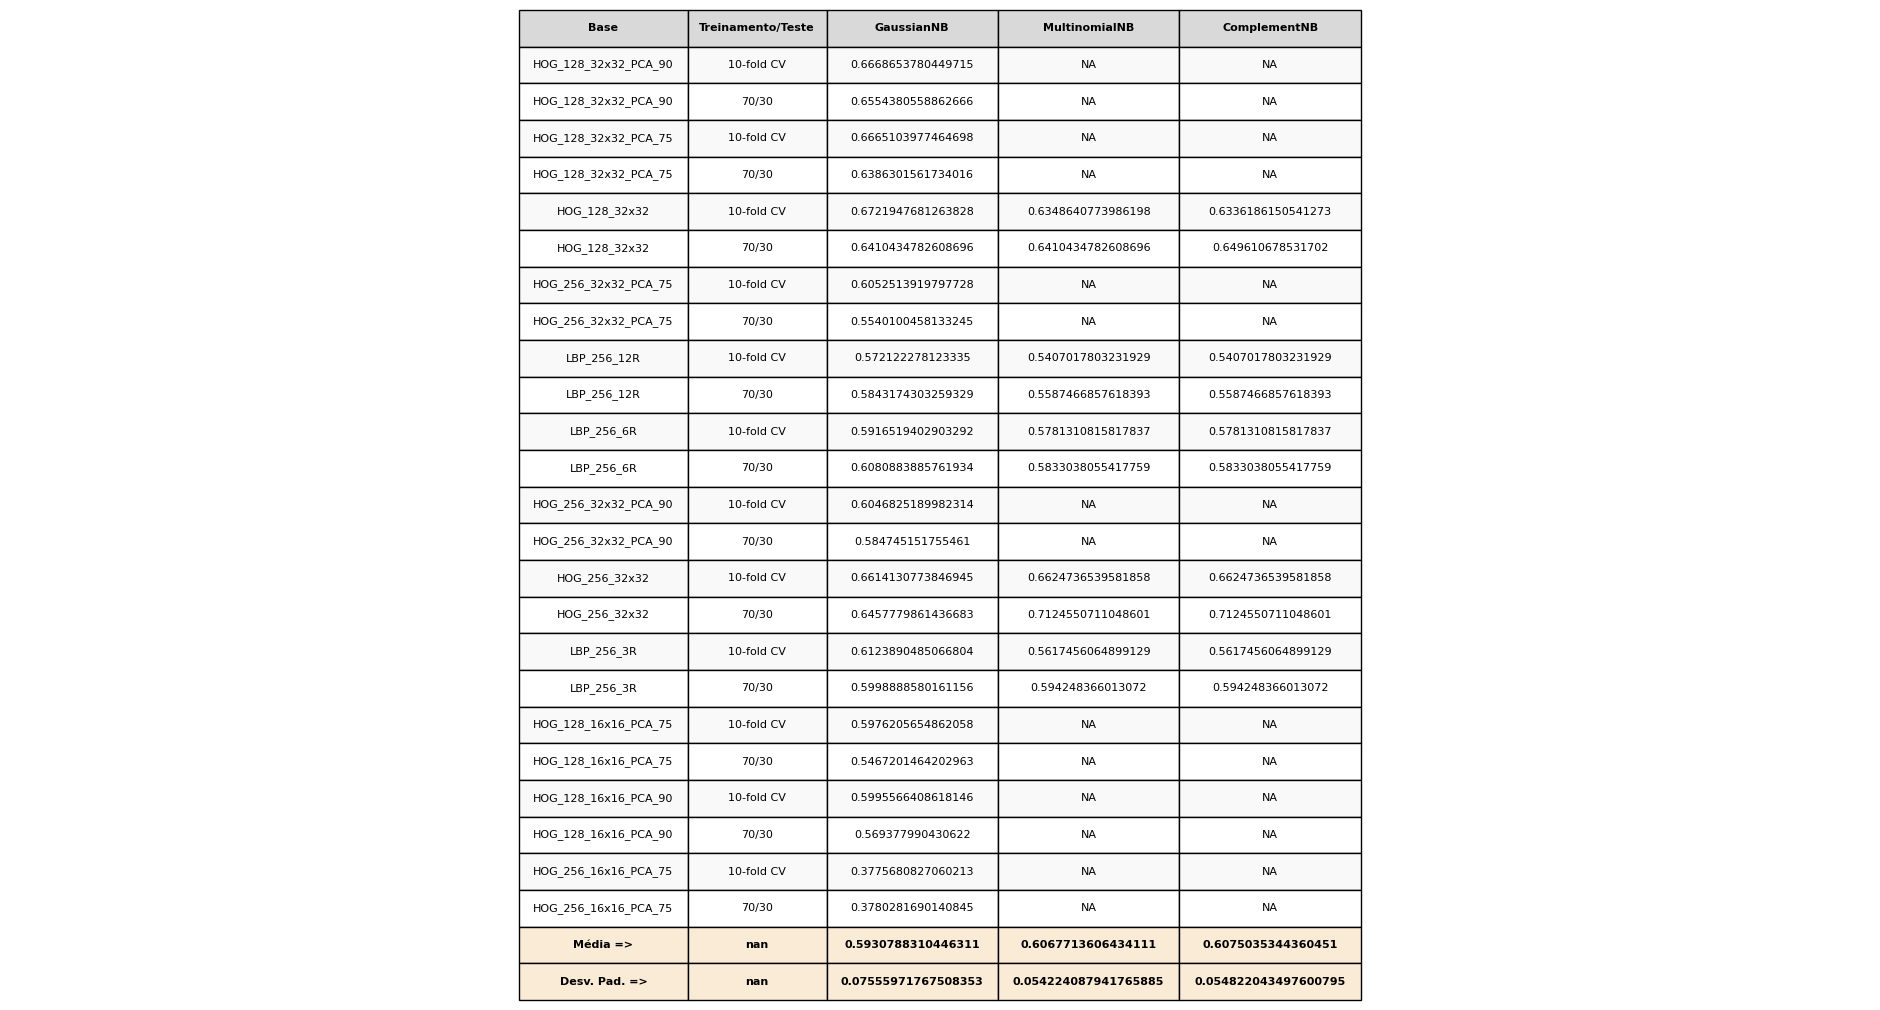

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.naive_bayes import GaussianNB, MultinomialNB, ComplementNB
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from google.colab import drive
import warnings

warnings.filterwarnings('ignore')

drive.mount('/content/drive')

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_top12 = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')
caminho_csv = os.path.join(caminho_drive, 'Resultados_NB_Planilha.csv')
caminho_pdf = os.path.join(caminho_drive, 'Resultados_NaiveBayes_SIGAA.pdf')

df_top12 = pd.read_csv(caminho_top12)
bases_top12 = df_top12.iloc[:, 0].tolist()

arquivos_bases = [f"{base}.csv" if not str(base).endswith('.csv') else base for base in bases_top12]

modelos = {
    'GaussianNB': GaussianNB(),
    'MultinomialNB': MultinomialNB(),
    'ComplementNB': ComplementNB()
}

resultados = []

for arquivo in arquivos_bases:
    arquivo_leitura = arquivo
    usar_pca = False
    n_comp_pca = None
    if "_PCA_" in arquivo:
        usar_pca = True
        partes = arquivo.replace('.csv', '').split('_PCA_')
        arquivo_leitura = partes[0] + '.csv'
        n_comp_pca = int(partes[1]) / 100.0

    caminho_arquivo = os.path.join(caminho_drive, arquivo_leitura)

    try:
        df = pd.read_csv(caminho_arquivo)
    except Exception:
        continue

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    # Verifica negativos na base original (HOG/LBP)
    X_numeric = X.select_dtypes(include=[np.number])
    tem_negativo = (X_numeric.values < 0).any() if not X_numeric.empty else False

    # Se usar PCA, inevitavelmente terá negativos
    if usar_pca:
        tem_negativo = True

    nome_base = arquivo.replace('.csv', '')

    for metodo in ['10-fold CV', '70/30']:
        linha_resultado = {
            'Base': nome_base,
            'Treinamento/Teste': metodo
        }

        for nome_modelo, modelo in modelos.items():
            if tem_negativo and nome_modelo in ['MultinomialNB', 'ComplementNB']:
                linha_resultado[nome_modelo] = 'NA'
                continue

            try:
                if usar_pca:
                    # StandardScaler antes do PCA para garantir a corretude do PCA
                    pipeline = Pipeline([
                        ('scaler', StandardScaler()),
                        ('pca', PCA(n_components=n_comp_pca, random_state=42)),
                        ('nb', modelo)
                    ])
                else:
                    # Sem PCA, usamos o modelo puro para manter a coerência anterior
                    pipeline = Pipeline([
                        ('nb', modelo)
                    ])

                if metodo == '10-fold CV':
                    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
                    scores = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_macro')
                    f1 = scores.mean()
                else:
                    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
                    pipeline.fit(X_train, y_train)
                    y_pred = pipeline.predict(X_test)
                    f1 = f1_score(y_test, y_pred, average='macro')

                linha_resultado[nome_modelo] = f1
            except Exception:
                linha_resultado[nome_modelo] = 'Erro'

        resultados.append(linha_resultado)

if not resultados:
    exit()

df_final = pd.DataFrame(resultados)

colunas_modelos = ['GaussianNB', 'MultinomialNB', 'ComplementNB']

medias = {'Base': 'Média =>', 'Treinamento/Teste': 'nan'}
desvios = {'Base': 'Desv. Pad. =>', 'Treinamento/Teste': 'nan'}

for col in colunas_modelos:
    serie_numerica = pd.to_numeric(df_final[col], errors='coerce')
    medias[col] = serie_numerica.mean()
    desvios[col] = serie_numerica.std()

df_final = pd.concat([df_final, pd.DataFrame([medias, desvios])], ignore_index=True)

df_final = df_final.astype(str)

df_final.to_csv(caminho_csv, index=False)

fig, ax = plt.subplots(figsize=(24, 12))
ax.axis('tight')
ax.axis('off')

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)

tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2.2)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > (len(df_final) - 2):
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
    else:
        if row % 2 == 0:
            cell.set_facecolor('#ffffff')
        else:
            cell.set_facecolor('#f9f9f9')

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)


# MLP

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== FASE 1: GRID SEARCH NA MELHOR BASE ===
Total de combinações no Grid Search: 1280
  Grid Search: 100/1280 combinações testadas...
  Grid Search: 200/1280 combinações testadas...
  Grid Search: 300/1280 combinações testadas...
  Grid Search: 400/1280 combinações testadas...
  Grid Search: 500/1280 combinações testadas...
  Grid Search: 600/1280 combinações testadas...
  Grid Search: 700/1280 combinações testadas...
  Grid Search: 800/1280 combinações testadas...
  Grid Search: 900/1280 combinações testadas...
  Grid Search: 1000/1280 combinações testadas...
  Grid Search: 1100/1280 combinações testadas...
  Grid Search: 1200/1280 combinações testadas...

✅ Grid Search concluído! Top 10 configurações encontradas.
  Config_1: F1=0.7291 | hidden=(150, 100) | activation=tanh | solver=adam | lr=0.1
  Config_2: F1=0.7291 | hidden=(150, 100) | activation=tanh | so

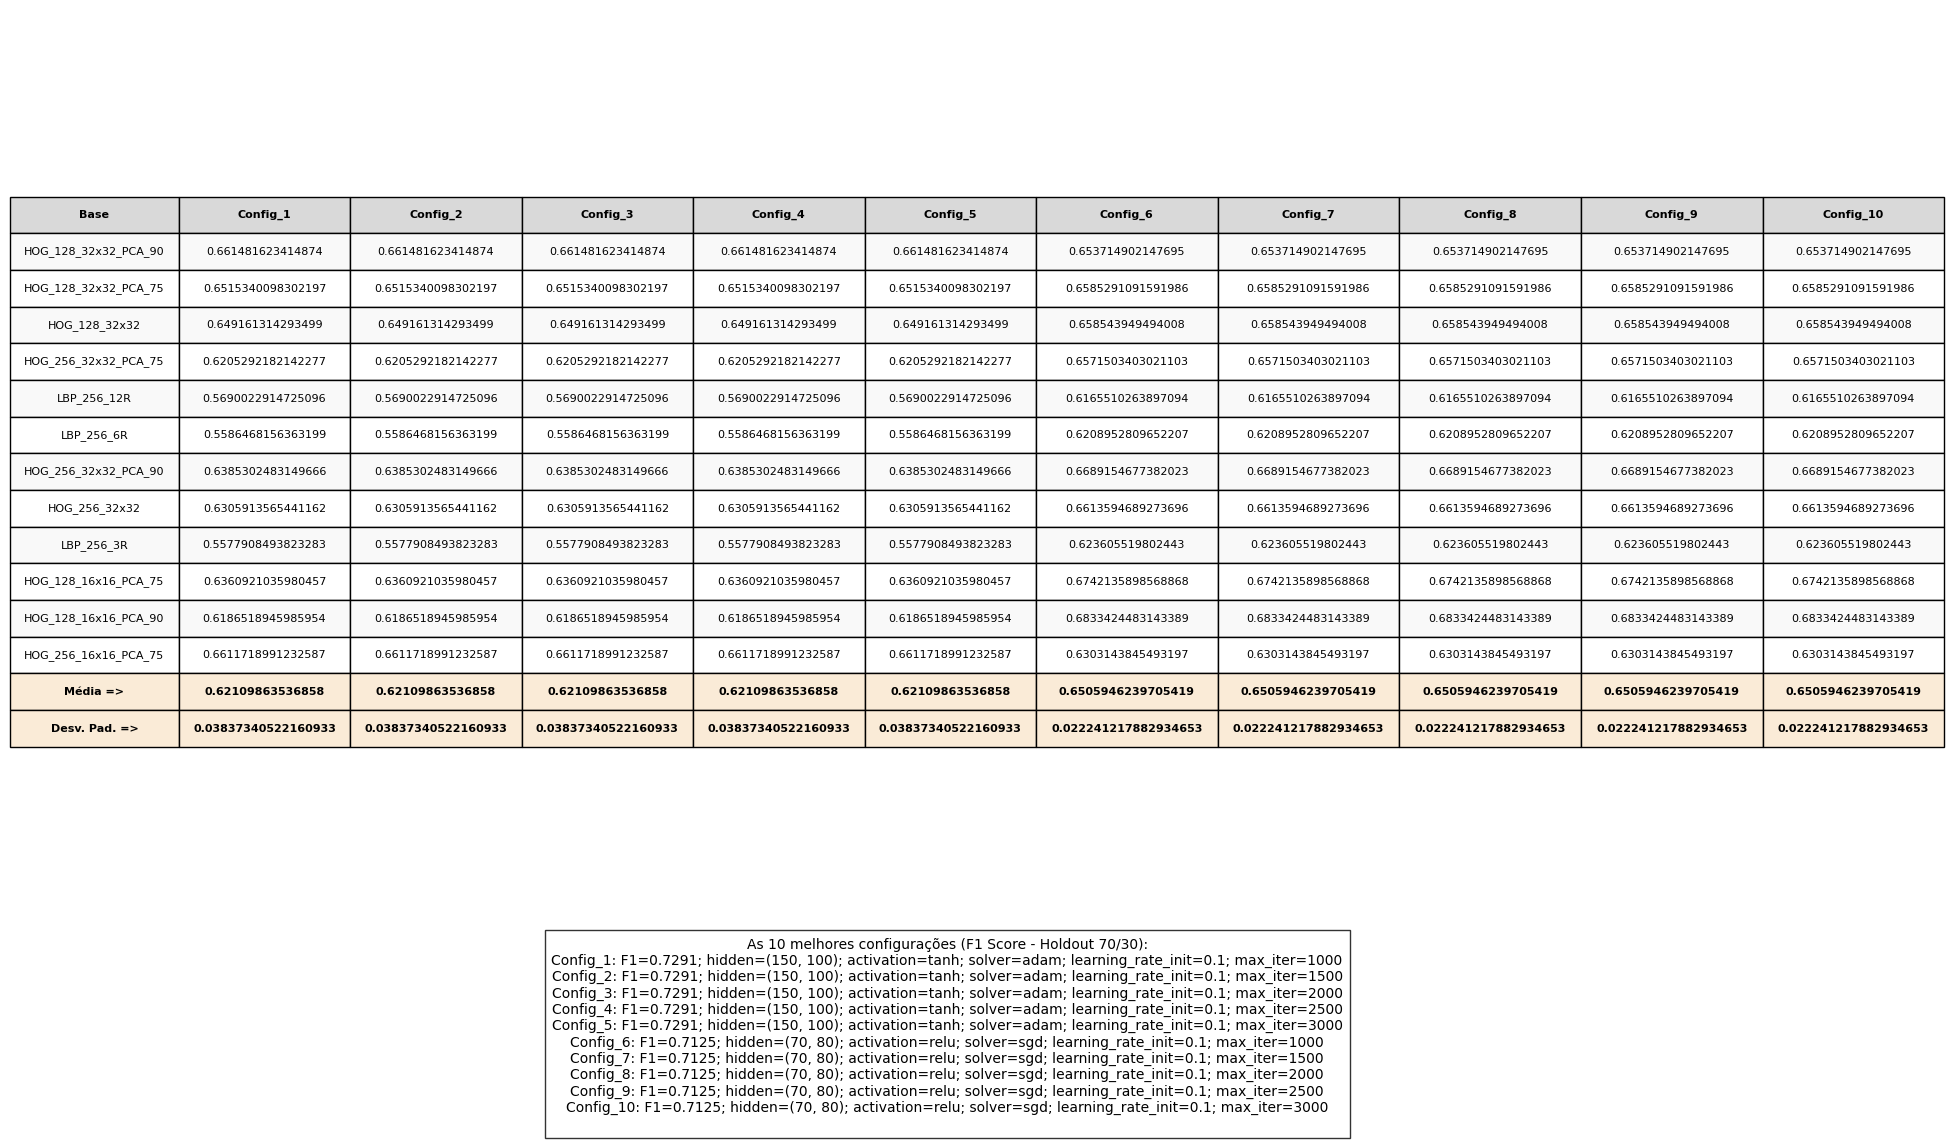

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, ParameterGrid
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from google.colab import drive
import warnings

warnings.filterwarnings('ignore')

# --- 1. Configuração Inicial ---
drive.mount('/content/drive')

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_top12 = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')
caminho_csv = os.path.join(caminho_drive, 'Resultados_MLP_Planilha.csv')
caminho_pdf = os.path.join(caminho_drive, 'Resultados_MLP_SIGAA.pdf')

df_top12 = pd.read_csv(caminho_top12)
bases_top12 = df_top12.iloc[:, 0].tolist()
arquivos_bases = [f"{base}.csv" if not str(base).endswith('.csv') else base for base in bases_top12]

# --- 2. Grid Search na Melhor Base (Holdout 70/30) ---
print("=== FASE 1: GRID SEARCH NA MELHOR BASE ===")

caminho_melhor_base = arquivos_bases[0]
usar_pca_best = False
n_comp_pca_best = None
if "_PCA_" in caminho_melhor_base:
    usar_pca_best = True
    partes = caminho_melhor_base.replace('.csv', '').split('_PCA_')
    caminho_melhor_base = partes[0] + '.csv'
    n_comp_pca_best = int(partes[1]) / 100.0

caminho_completo = os.path.join(caminho_drive, caminho_melhor_base)
df_melhor = pd.read_csv(caminho_completo)

X_melhor = df_melhor.iloc[:, :-1].values
y_texto = df_melhor.iloc[:, -1].values

le = LabelEncoder()
y_melhor = le.fit_transform(y_texto)

X_train, X_test, y_train, y_test = train_test_split(
    X_melhor, y_melhor, test_size=0.3, random_state=42, stratify=y_melhor
)

param_grid = {
    'hidden_layer_sizes': [(100,), (120,), (150,), (200,), (250,), (70, 80), (100, 100), (150, 100)],
    'activation': ['identity', 'logistic', 'relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.0001, 0.001, 0.01, 0.1],
    'max_iter': [1000, 1500, 2000, 2500, 3000]
}

grid = list(ParameterGrid(param_grid))
print(f"Total de combinações no Grid Search: {len(grid)}")

resultados_holdout = []
for idx_param, params in enumerate(grid):
    if (idx_param + 1) % 100 == 0:
        print(f"  Grid Search: {idx_param + 1}/{len(grid)} combinações testadas...")

    try:
        if usar_pca_best:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp_pca_best, random_state=42)),
                ('mlp', MLPClassifier(**params, random_state=42, early_stopping=True))
            ])
        else:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('mlp', MLPClassifier(**params, random_state=42, early_stopping=True))
            ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        f1 = f1_score(y_test, y_pred, average='macro')
        resultados_holdout.append({'params': params, 'f1': f1})
    except Exception as e:
        print(f"Erro na config {params}: {e}")
        continue

resultados_holdout.sort(key=lambda x: x['f1'], reverse=True)
top_10_configs = resultados_holdout[:10]

print(f"\n✅ Grid Search concluído! Top 10 configurações encontradas.")
for i, config in enumerate(top_10_configs):
    p = config['params']
    print(f"  Config_{i+1}: F1={config['f1']:.4f} | hidden={p['hidden_layer_sizes']} | "
          f"activation={p['activation']} | solver={p['solver']} | lr={p['learning_rate_init']}")

# --- 3. Avaliação nas 12 Bases (10-fold CV) ---
print("\n=== FASE 2: AVALIAÇÃO NAS 12 BASES (TOP 10 CONFIGS) ===")

resultados_cv = []

for arquivo in arquivos_bases:
    arquivo_leitura = arquivo
    usar_pca = False
    n_comp_pca = None
    if "_PCA_" in arquivo:
        usar_pca = True
        partes = arquivo.replace('.csv', '').split('_PCA_')
        arquivo_leitura = partes[0] + '.csv'
        n_comp_pca = int(partes[1]) / 100.0

    caminho_arquivo = os.path.join(caminho_drive, arquivo_leitura)
    try:
        df = pd.read_csv(caminho_arquivo)
    except Exception as e:
        print(f"❌ Erro ao ler base {arquivo}: {e}")
        continue

    X = df.iloc[:, :-1].values
    y_texto = df.iloc[:, -1].values
    y = le.transform(y_texto)

    nome_base = arquivo.replace('.csv', '')
    linha_resultado = {'Base': nome_base}

    for i, config in enumerate(top_10_configs):
        nome_config = f'Config_{i+1}'
        try:
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
            scores_cv = []

            for train_idx, test_idx in skf.split(X, y):
                X_train_f, X_test_f = X[train_idx], X[test_idx]
                y_train_f, y_test_f = y[train_idx], y[test_idx]

                scaler = StandardScaler()
                X_train_f = scaler.fit_transform(X_train_f)
                X_test_f = scaler.transform(X_test_f)

                if usar_pca:
                    pca = PCA(n_components=n_comp_pca, random_state=42)
                    X_train_f = pca.fit_transform(X_train_f)
                    X_test_f = pca.transform(X_test_f)

                mlp = MLPClassifier(**config['params'], random_state=42, early_stopping=True)
                mlp.fit(X_train_f, y_train_f)
                y_pred_f = mlp.predict(X_test_f)
                scores_cv.append(f1_score(y_test_f, y_pred_f, average='macro'))

            linha_resultado[nome_config] = np.mean(scores_cv)
        except Exception as e:
            print(f"  Erro na config {i+1}, base {nome_base}: {e}")
            linha_resultado[nome_config] = 'Erro'

    resultados_cv.append(linha_resultado)
    print(f"✅ Processada: {nome_base}")

if not resultados_cv:
    print("Nenhum resultado gerado. Encerrando.")
    exit()

# --- 4. Montagem da Planilha Final ---
df_final = pd.DataFrame(resultados_cv)
colunas_configs = [f'Config_{i+1}' for i in range(len(top_10_configs))]

medias = {'Base': 'Média =>'}
desvios = {'Base': 'Desv. Pad. =>'}

for col in colunas_configs:
    if col in df_final.columns:
        serie_numerica = pd.to_numeric(df_final[col], errors='coerce')
        medias[col] = serie_numerica.mean()
        desvios[col] = serie_numerica.std()

df_final = pd.concat([df_final, pd.DataFrame([medias, desvios])], ignore_index=True)
df_final = df_final.astype(str)

df_final.to_csv(caminho_csv, index=False)
print(f"\n✅ Planilha salva: {caminho_csv}")

# --- 5. Geração do PDF ---
fig, ax = plt.subplots(figsize=(24, 12))
ax.axis('tight')
ax.axis('off')

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2.2)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > (len(df_final) - 2):
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
    else:
        if row % 2 == 0:
            cell.set_facecolor('#ffffff')
        else:
            cell.set_facecolor('#f9f9f9')

texto_configs = "As 10 melhores configurações (F1 Score - Holdout 70/30):\n"
for i, config in enumerate(top_10_configs):
    p = config['params']
    texto_configs += f"Config_{i+1}: F1={config['f1']:.4f}; hidden={p['hidden_layer_sizes']}; activation={p['activation']}; solver={p['solver']}; learning_rate_init={p['learning_rate_init']}; max_iter={p['max_iter']}\n"

plt.figtext(0.5, -0.05, texto_configs, ha='center', fontsize=10, bbox={"facecolor": "white", "alpha": 0.8, "pad": 5}, wrap=True)

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ PDF gerado: {caminho_pdf}")


# Bagging

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processando base 1/12: HOG_128_32x32_PCA_90
Processando base 2/12: HOG_128_32x32_PCA_75
Processando base 3/12: HOG_128_32x32
Processando base 4/12: HOG_256_32x32_PCA_75
Processando base 5/12: LBP_256_12R
Processando base 6/12: LBP_256_6R
Processando base 7/12: HOG_256_32x32_PCA_90
Processando base 8/12: HOG_256_32x32
Processando base 9/12: LBP_256_3R
Processando base 10/12: HOG_128_16x16_PCA_75
Processando base 11/12: HOG_128_16x16_PCA_90
Processando base 12/12: HOG_256_16x16_PCA_75

ANÁLISE ESTATÍSTICA (10-fold CV)
Estatística de Friedman: 87.6150
Valor-p: 4.8823e-14

CONCLUSÃO: Há diferença estatística significativa entre os modelos (p < 0.05).
Decisão: Escolhemos o modelo com o melhor desempenho médio.
-> VENCEDOR: MLP (10) (F1 Média CV: 0.6821)

Processo concluído! Tabela salva em: /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Bagging_SI

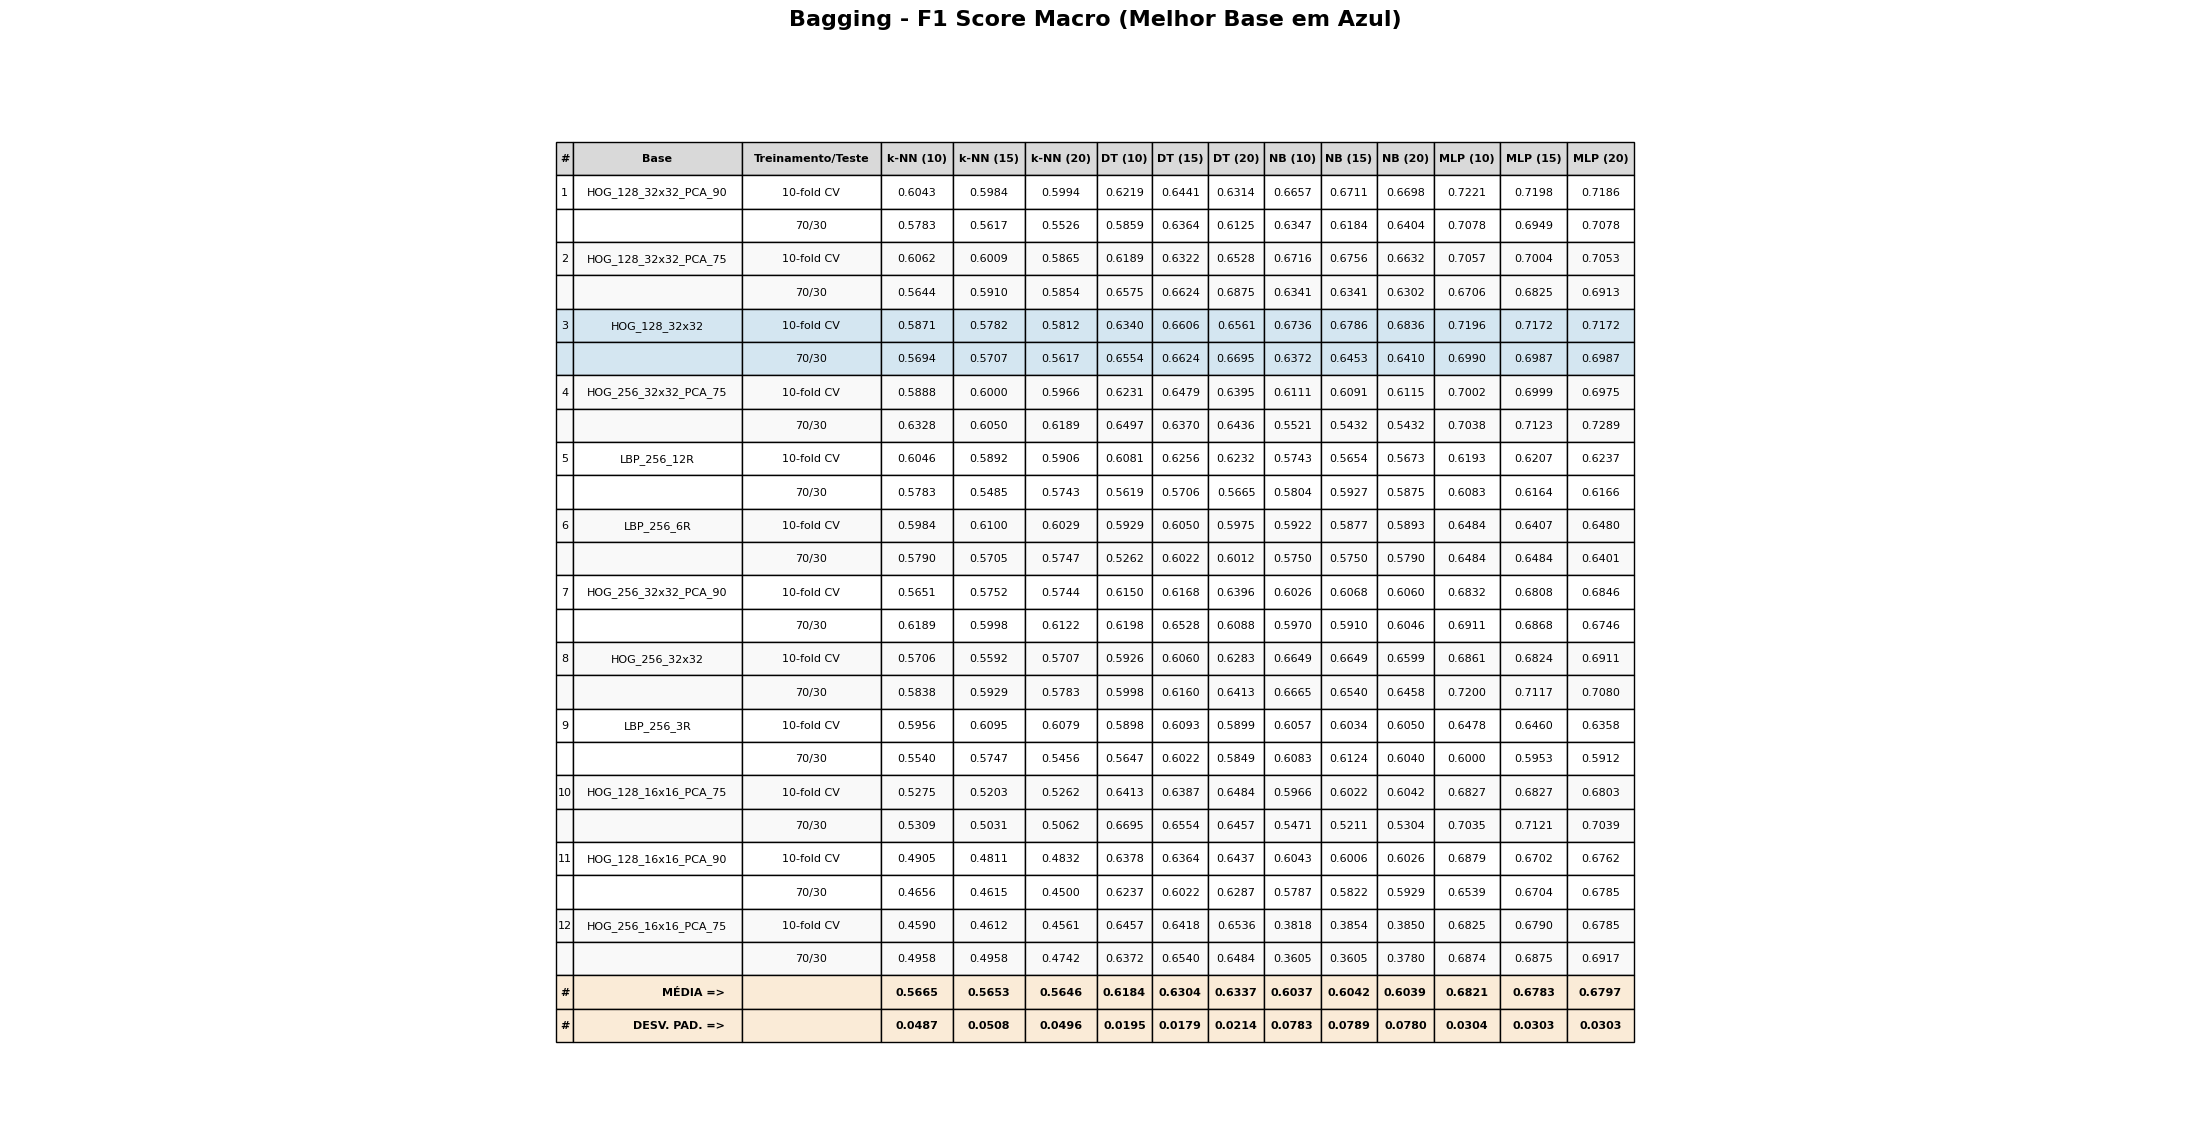

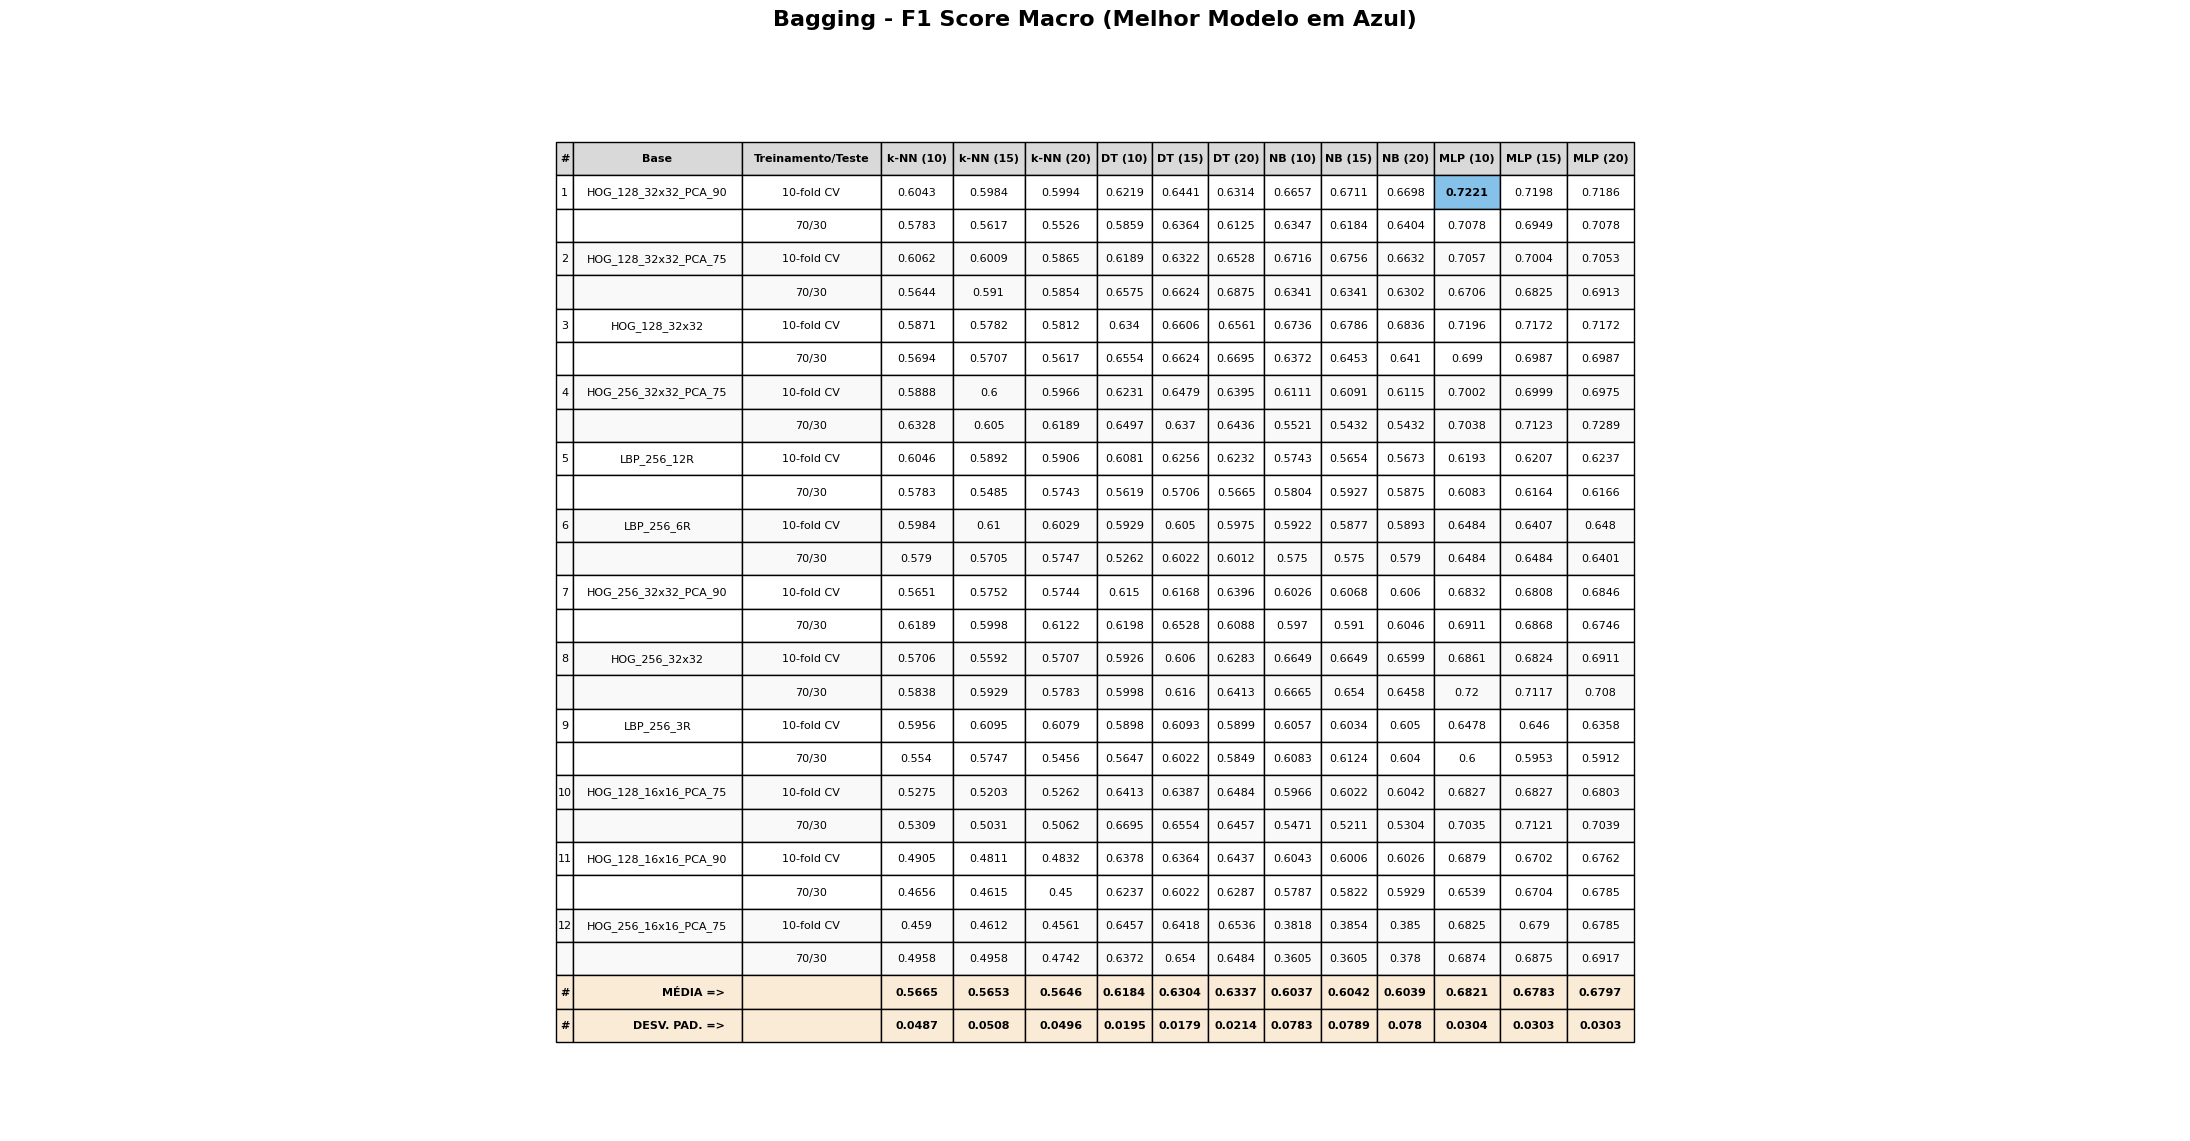

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from google.colab import drive
import warnings

from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# --- 1. Configuração Inicial e Montagem do Drive ---
drive.mount('/content/drive')

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_top12 = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')
caminho_csv = os.path.join(caminho_drive, 'Resultados_Bagging_Estatistica.csv')
caminho_pdf = os.path.join(caminho_drive, 'Resultados_Bagging_SIGAA_Azul.pdf')

try:
    df_top12 = pd.read_csv(caminho_top12)
    bases_top12 = df_top12.iloc[:, 0].tolist()
    arquivos_bases = [f"{base}.csv" if not str(base).endswith('.csv') else base for base in bases_top12]
except Exception as e:
    print(f"Erro ao ler lista de bases: {e}.")
    arquivos_bases = []

# --- 2. Definição dos Modelos Base (com k-NN ajustado) e Bagging ---
estimadores_base = {
    'k-NN': KNeighborsClassifier(n_neighbors=4), # Melhor configuração definida
    'DT': DecisionTreeClassifier(random_state=42),
    'NB': GaussianNB(),
    'MLP': MLPClassifier(random_state=42, max_iter=1000, early_stopping=False)
}

n_estimators_list = [10, 15, 20]

colunas_modelos = []
for nome_modelo in estimadores_base.keys():
    for n in n_estimators_list:
        colunas_modelos.append(f"{nome_modelo} ({n})")

colunas_df = ['#', 'Base', 'Treinamento/Teste'] + colunas_modelos
resultados = []

# --- 3. Loop de Treinamento e Avaliação ---
for idx, arquivo in enumerate(arquivos_bases):
    arquivo_leitura = arquivo
    usar_pca = False
    n_comp_pca = None
    if "_PCA_" in arquivo:
        usar_pca = True
        partes = arquivo.replace('.csv', '').split('_PCA_')
        arquivo_leitura = partes[0] + '.csv'
        n_comp_pca = int(partes[1]) / 100.0

    caminho_arquivo = os.path.join(caminho_drive, arquivo_leitura)
    nome_base = arquivo.replace('.csv', '')
    print(f"Processando base {idx+1}/{len(arquivos_bases)}: {nome_base}")

    try:
        df = pd.read_csv(caminho_arquivo)
    except Exception as e:
        print(f"Erro ao ler base {arquivo_leitura}: {e}")
        continue

    X = df.iloc[:, :-1].values
    y_texto = df.iloc[:, -1].values
    le = LabelEncoder()
    y = le.fit_transform(y_texto)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    linha_cv = {'#': str(idx+1), 'Base': nome_base, 'Treinamento/Teste': '10-fold CV'}
    linha_holdout = {'#': '', 'Base': '', 'Treinamento/Teste': '70/30'}

    # --- 1. Holdout Avaliação (Apenas 1 PCA fit) ---
    if usar_pca:
        scaler = StandardScaler()
        X_train_h = scaler.fit_transform(X_train)
        X_test_h = scaler.transform(X_test)

        pca = PCA(n_components=n_comp_pca, random_state=42)
        X_train_h = pca.fit_transform(X_train_h)
        X_test_h = pca.transform(X_test_h)
    else:
        scaler = StandardScaler()
        X_train_h = scaler.fit_transform(X_train)
        X_test_h = scaler.transform(X_test)

    for nome_modelo, estimador in estimadores_base.items():
        for n in n_estimators_list:
            col_name = f"{nome_modelo} ({n})"
            bagging = BaggingClassifier(estimator=estimador, n_estimators=n, random_state=42, n_jobs=-1)
            try:
                bagging.fit(X_train_h, y_train)
                y_pred_h = bagging.predict(X_test_h)
                linha_holdout[col_name] = round(f1_score(y_test, y_pred_h, average='macro'), 4)
            except Exception as e:
                print(f"Erro no Holdout ({col_name}): {e}")
                linha_holdout[col_name] = np.nan

    # --- 2. 10-fold CV Manual Otimizado ---
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores_cv_dict = {}
    for nome_modelo in estimadores_base.keys():
        for n in n_estimators_list:
            scores_cv_dict[f"{nome_modelo} ({n})"] = []

    for train_idx, test_idx in skf.split(X, y):
        X_train_f, X_test_f = X[train_idx], X[test_idx]
        y_train_f, y_test_f = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train_f = scaler.fit_transform(X_train_f)
        X_test_f = scaler.transform(X_test_f)

        if usar_pca:
            pca = PCA(n_components=n_comp_pca, random_state=42)
            X_train_f = pca.fit_transform(X_train_f)
            X_test_f = pca.transform(X_test_f)

        for nome_modelo, estimador in estimadores_base.items():
            for n in n_estimators_list:
                col_name = f"{nome_modelo} ({n})"
                bagging = BaggingClassifier(estimator=estimador, n_estimators=n, random_state=42, n_jobs=-1)
                try:
                    bagging.fit(X_train_f, y_train_f)
                    y_pred_f = bagging.predict(X_test_f)
                    scores_cv_dict[col_name].append(f1_score(y_test_f, y_pred_f, average='macro'))
                except Exception as e:
                    print(f"Erro no CV ({col_name}): {e}")
                    pass

    for col_name in scores_cv_dict.keys():
        if len(scores_cv_dict[col_name]) > 0:
            linha_cv[col_name] = round(np.mean(scores_cv_dict[col_name]), 4)
        else:
            linha_cv[col_name] = np.nan

    resultados.append(linha_cv)
    resultados.append(linha_holdout)

if not resultados:
    print("Nenhum resultado gerado.")
    exit()

df_final = pd.DataFrame(resultados, columns=colunas_df)

# --- 4. Análise Estatística (Teste de Friedman) ---
print("\n" + "="*50)
print("ANÁLISE ESTATÍSTICA (10-fold CV)")
print("="*50)

# Isolando os dados do 10-fold CV para a estatística
df_cv = df_final[df_final['Treinamento/Teste'] == '10-fold CV'].copy()
df_cv[colunas_modelos] = df_cv[colunas_modelos].apply(pd.to_numeric, errors='coerce')

# Preenchendo NaNs com a média da coluna (caso algum modelo falhe)
df_cv_stats = df_cv[colunas_modelos].fillna(df_cv[colunas_modelos].mean())

# Executando o teste de Friedman
dados_modelos = [df_cv_stats[col].values for col in colunas_modelos]
stat, p_value = friedmanchisquare(*dados_modelos)

medias_cv = df_cv_stats.mean().to_dict()
modelo_maior_media = max(medias_cv, key=medias_cv.get)

# Ordem teórica de complexidade (do mais simples pro mais complexo)
ordem_complexidade = [
    'NB (10)', 'NB (15)', 'NB (20)',
    'DT (10)', 'DT (15)', 'DT (20)',
    'k-NN (10)', 'k-NN (15)', 'k-NN (20)',
    'MLP (10)', 'MLP (15)', 'MLP (20)'
]

print(f"Estatística de Friedman: {stat:.4f}")
print(f"Valor-p: {p_value:.4e}\n")

if p_value < 0.05:
    print("CONCLUSÃO: Há diferença estatística significativa entre os modelos (p < 0.05).")
    print(f"Decisão: Escolhemos o modelo com o melhor desempenho médio.")
    print(f"-> VENCEDOR: {modelo_maior_media} (F1 Média CV: {medias_cv[modelo_maior_media]:.4f})")
else:
    print("CONCLUSÃO: NÃO há diferença estatística significativa entre os modelos (p >= 0.05).")
    print("Decisão: Escolhemos o modelo mais simples como vencedor.")
    # Buscando o modelo mais simples que não tenha falhado e esteja na nossa lista
    modelo_mais_simples = next((m for m in ordem_complexidade if m in colunas_modelos), None)
    print(f"-> VENCEDOR (Por Complexidade): {modelo_mais_simples}")
print("="*50 + "\n")

# --- 5. Identificando a Melhor Base para Colorir de Azul ---
df_cv['Media_Por_Base'] = df_cv[colunas_modelos].mean(axis=1)
nome_melhor_base = df_cv.loc[df_cv['Media_Por_Base'].idxmax(), 'Base']

# --- 6. Médias e Desvios Padrão para a Tabela ---
linha_media = {'#': '#', 'Base': 'MÉDIA =>', 'Treinamento/Teste': ''}
linha_desvio = {'#': '#', 'Base': 'DESV. PAD. =>', 'Treinamento/Teste': ''}

for col in colunas_modelos:
    linha_media[col] = f"{df_cv_stats[col].mean():.4f}"
    linha_desvio[col] = f"{df_cv_stats[col].std():.4f}"

df_final = pd.concat([df_final, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)

# Formatação em string para a tabela do Matplotlib
for col in colunas_modelos:
    df_final[col] = df_final[col].apply(lambda x: f"{float(x):.4f}" if pd.notna(x) and str(x).replace('.','').isdigit() else x)

df_final.fillna('', inplace=True)
df_final.to_csv(caminho_csv, index=False)

# --- 7. Geração do PDF com Matplotlib (Com Azul na Melhor Base) ---
fig, ax = plt.subplots(figsize=(28, 14))
ax.axis('tight')
ax.axis('off')

plt.title("Bagging - F1 Score Macro (Melhor Base em Azul)", fontweight='bold', fontsize=16, pad=20)

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2)

total_linhas = len(df_final)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > total_linhas - 2:
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
        if col == 1: cell.set_text_props(ha='right')
    else:
        # Descobrir o nome da base atual para essa linha
        # Como o nome da base só aparece na linha ímpar (10-fold), usamos row e row-1 para o holdout
        base_atual = df_final.iloc[row-1]['Base']
        if not base_atual: # Se for vazio, é a linha do holdout logo abaixo
            base_atual = df_final.iloc[row-2]['Base']

        # Se for a melhor base, pinta de azul claro. Senão, mantém o zebrado normal.
        if base_atual == nome_melhor_base:
            cell.set_facecolor('#d4e6f1') # Azul claro
        else:
            base_row_index = (row - 1) // 2
            if base_row_index % 2 == 0:
                cell.set_facecolor('#ffffff')
            else:
                cell.set_facecolor('#f9f9f9')

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"Processo concluído! Tabela salva em: {caminho_pdf}")

import os
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Configuração de Caminhos ---
# Ajuste se estiver rodando localmente ou mude o caminho do Colab
caminho_csv = '/content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Bagging_Estatistica.csv'
caminho_pdf = '/content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Bagging_SIGAA_Grafico_Refeito.pdf'

# Lendo os dados já processados
try:
    df_final = pd.read_csv(caminho_csv)
    # Garante que os NaN (células vazias) sejam tratados como strings vazias para o plot
    df_final.fillna('', inplace=True)
    print("CSV carregado com sucesso!")
except FileNotFoundError:
    print(f"Erro: O arquivo {caminho_csv} não foi encontrado.")
    exit()

# --- 2. Descobrindo a Célula Vencedora ---
# Identificamos as colunas que representam os modelos (da 4ª coluna em diante)
colunas_modelos = df_final.columns[3:]

# Isolamos a linha de médias e os dados de 10-fold CV
linha_media = df_final[df_final['Base'] == 'MÉDIA =>']
df_cv = df_final[df_final['Treinamento/Teste'] == '10-fold CV'].copy()

# A) Descobrir a Configuração Vencedora (a que teve a maior média geral)
medias = linha_media[colunas_modelos].astype(float).iloc[0]
configuracao_vencedora = medias.idxmax()

# B) Descobrir a Melhor Base para essa configuração
# Converte a coluna vencedora para float apenas para achar o índice do valor máximo
valores_cv_vencedor = pd.to_numeric(df_cv[configuracao_vencedora], errors='coerce')
idx_melhor_base = valores_cv_vencedor.idxmax()
base_do_melhor_modelo = df_cv.loc[idx_melhor_base, 'Base']

print(f"-> VENCEDOR ENCONTRADO NO CSV: {configuracao_vencedora}")
print(f"-> MELHOR DESEMPENHO NA BASE: {base_do_melhor_modelo}")

# --- 3. Geração do PDF com Matplotlib ---
print("Gerando o gráfico atualizado...")

fig, ax = plt.subplots(figsize=(28, 14))
ax.axis('tight')
ax.axis('off')

plt.title("Bagging - F1 Score Macro (Melhor Modelo em Azul)", fontweight='bold', fontsize=16, pad=20)

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(8)
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2)

total_linhas = len(df_final)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        # Cabeçalho
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > total_linhas - 2:
        # Linhas de Média e Desvio Padrão
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
        if col == 1: cell.set_text_props(ha='right')
    else:
        # Identifica em qual célula estamos iterando
        nome_coluna_atual = df_final.columns[col]

        # Lógica para pegar o nome da base atual corretamente
        base_atual = df_final.iloc[row-1]['Base']
        if not base_atual: # Se for a linha do Holdout, puxa o nome da base da linha de cima
            base_atual = df_final.iloc[row-2]['Base']

        tipo_teste = df_final.iloc[row-1]['Treinamento/Teste']

        # --- APLICAÇÃO DA COR AZUL NA CÉLULA EXATA ---
        if (nome_coluna_atual == configuracao_vencedora and
            base_atual == base_do_melhor_modelo and
            tipo_teste == '10-fold CV'):

            cell.set_facecolor('#85c1e9') # Azul forte
            cell.set_text_props(weight='bold')
        else:
            # Zebrado normal para o restante da tabela
            base_row_index = (row - 1) // 2
            if base_row_index % 2 == 0:
                cell.set_facecolor('#ffffff')
            else:
                cell.set_facecolor('#f9f9f9')

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ Processo concluído! Tabela salva em: {caminho_pdf}")


# Random Forest

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processando base 1/12: HOG_128_32x32_PCA_90
Processando base 2/12: HOG_128_32x32_PCA_75
Processando base 3/12: HOG_128_32x32
Processando base 4/12: HOG_256_32x32_PCA_75
Processando base 5/12: LBP_256_12R
Processando base 6/12: LBP_256_6R
Processando base 7/12: HOG_256_32x32_PCA_90
Processando base 8/12: HOG_256_32x32
Processando base 9/12: LBP_256_3R
Processando base 10/12: HOG_128_16x16_PCA_75
Processando base 11/12: HOG_128_16x16_PCA_90
Processando base 12/12: HOG_256_16x16_PCA_75

ANÁLISE ESTATÍSTICA (10-fold CV) - RANDOM FOREST (C/ MAX_DEPTH)
Estatística de Friedman: 59.7778
Valor-p: 1.6719e-10

CONCLUSÃO: Há diferença estatística significativa (p < 0.05).
-> VENCEDOR (Melhor Média): Entropy (100) (F1: 0.6581)

Gerando o PDF...
Processo concluído! Tabela salva em: /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_RF_SIGAA.pdf


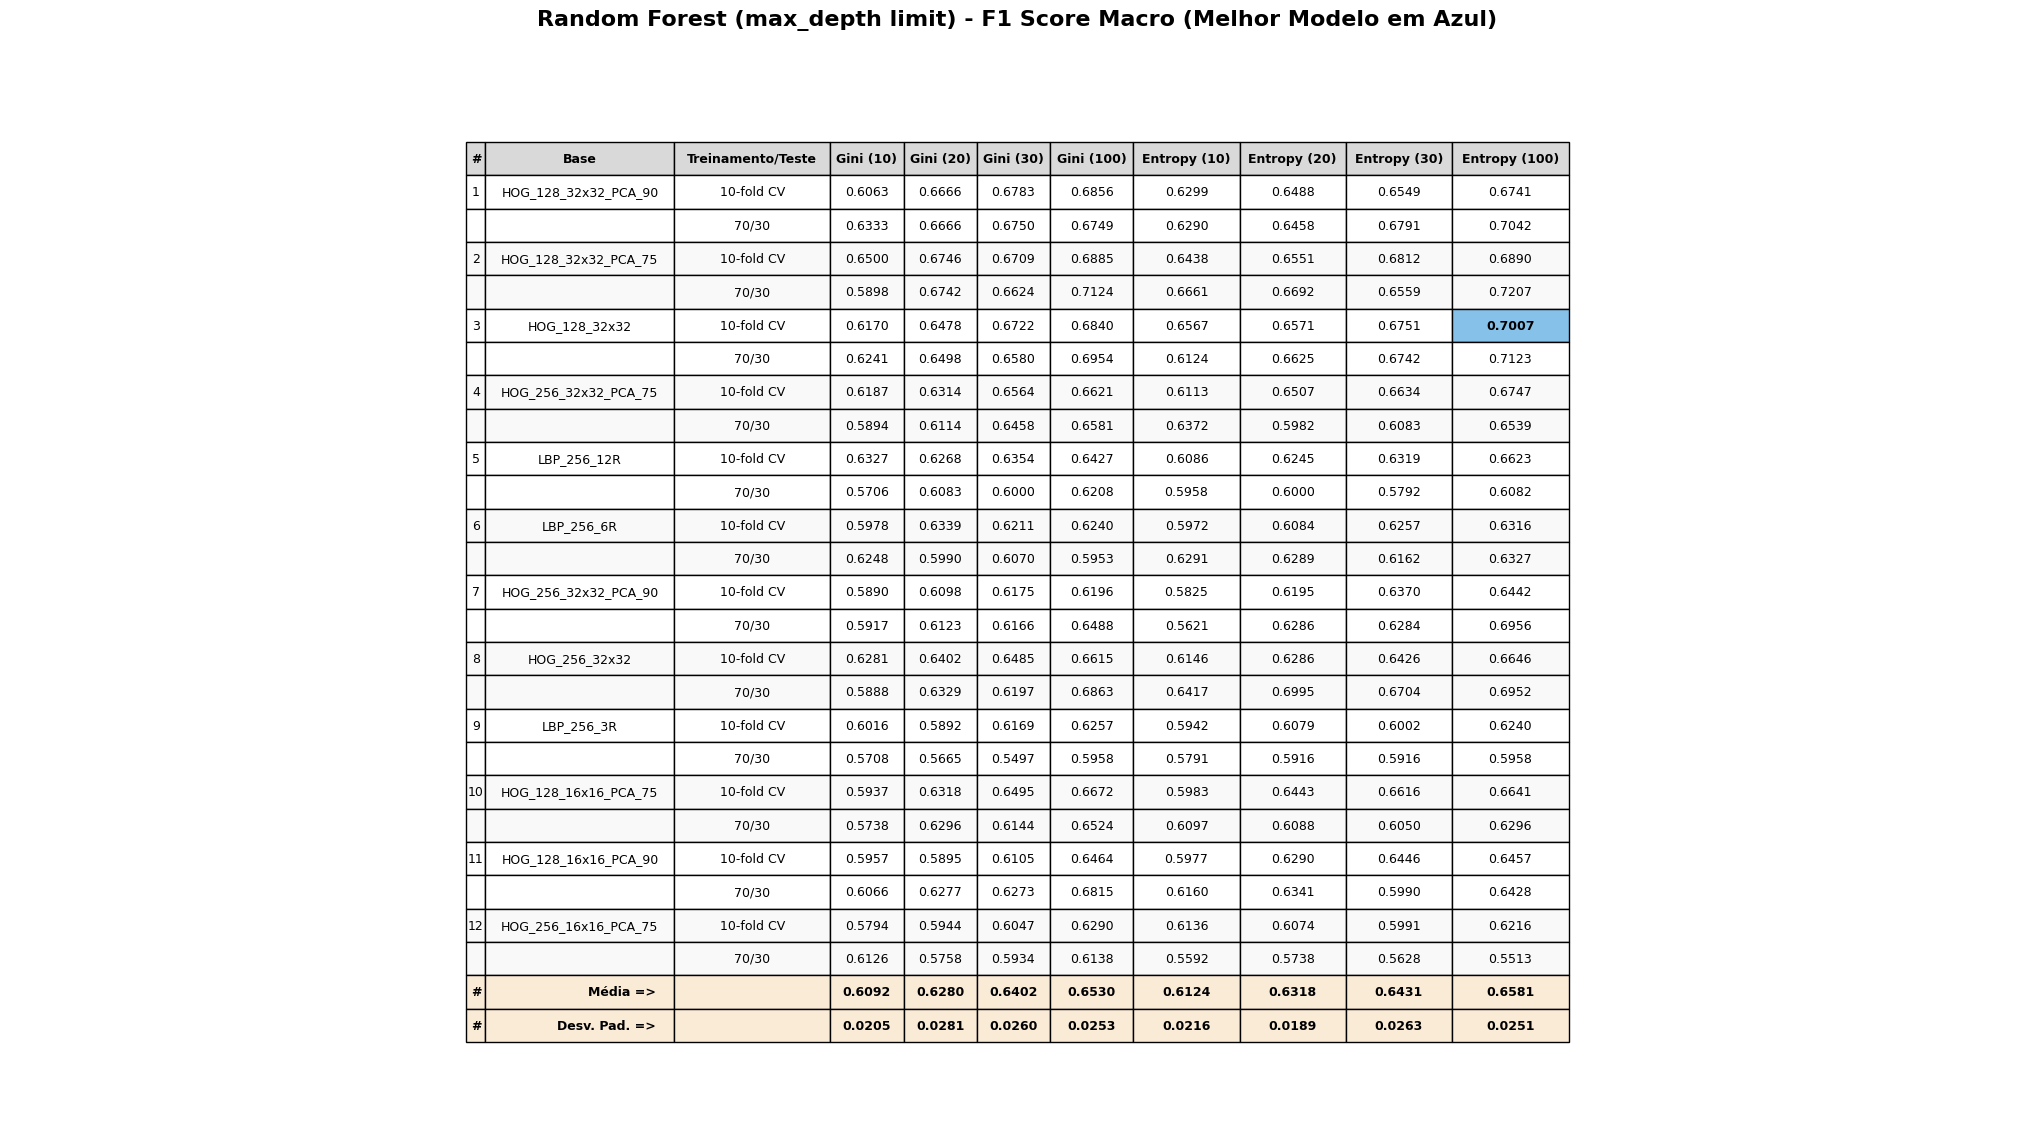

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from google.colab import drive
import warnings

# Importando o Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# --- 1. Configuração Inicial e Montagem do Drive ---
drive.mount('/content/drive')

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_top12 = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')
caminho_csv = os.path.join(caminho_drive, 'Resultados_RF_Estatistica.csv')
caminho_pdf = os.path.join(caminho_drive, 'Resultados_RF_SIGAA.pdf')

try:
    df_top12 = pd.read_csv(caminho_top12)
    bases_top12 = df_top12.iloc[:, 0].tolist()
    arquivos_bases = [f"{base}.csv" if not str(base).endswith('.csv') else base for base in bases_top12]
except Exception as e:
    print(f"Erro ao ler lista de bases: {e}. Certifique-se de que o arquivo existe.")
    arquivos_bases = []

# --- 2. Definição das Configurações do Random Forest ---
criterios = ['gini', 'entropy']
n_estimators_list = [10, 20, 30, 100]

colunas_modelos = []
for criterio in criterios:
    for n in n_estimators_list:
        nome_formatado = 'Gini' if criterio == 'gini' else 'Entropy'
        colunas_modelos.append(f"{nome_formatado} ({n})")

colunas_df = ['#', 'Base', 'Treinamento/Teste'] + colunas_modelos
resultados = []

for idx, arquivo in enumerate(arquivos_bases):
    arquivo_leitura = arquivo
    usar_pca = False
    n_comp_pca = None
    if "_PCA_" in arquivo:
        usar_pca = True
        partes = arquivo.replace('.csv', '').split('_PCA_')
        arquivo_leitura = partes[0] + '.csv'
        n_comp_pca = int(partes[1]) / 100.0

    caminho_arquivo = os.path.join(caminho_drive, arquivo_leitura)
    nome_base = arquivo.replace('.csv', '')
    print(f"Processando base {idx+1}/{len(arquivos_bases)}: {nome_base}")

    try:
        df = pd.read_csv(caminho_arquivo)
    except Exception as e:
        print(f"Erro ao ler base {arquivo_leitura}: {e}")
        continue

    X = df.iloc[:, :-1].values
    y_texto = df.iloc[:, -1].values
    le = LabelEncoder()
    y = le.fit_transform(y_texto)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    linha_cv = {'#': str(idx+1), 'Base': nome_base, 'Treinamento/Teste': '10-fold CV'}
    linha_holdout = {'#': '', 'Base': '', 'Treinamento/Teste': '70/30'}

    # --- 1. Holdout Avaliação (Apenas 1 PCA fit) ---
    if usar_pca:
        scaler = StandardScaler()
        X_train_h = scaler.fit_transform(X_train)
        X_test_h = scaler.transform(X_test)

        pca = PCA(n_components=n_comp_pca, random_state=42)
        X_train_h = pca.fit_transform(X_train_h)
        X_test_h = pca.transform(X_test_h)
    else:
        scaler = StandardScaler()
        X_train_h = scaler.fit_transform(X_train)
        X_test_h = scaler.transform(X_test)

    for criterio in criterios:
        for n in n_estimators_list:
            nome_formatado = 'Gini' if criterio == 'gini' else 'Entropy'
            col_name = f"{nome_formatado} ({n})"
            rf = RandomForestClassifier(n_estimators=n, criterion=criterio, max_depth=10, random_state=42, n_jobs=-1)
            try:
                rf.fit(X_train_h, y_train)
                y_pred_h = rf.predict(X_test_h)
                linha_holdout[col_name] = round(f1_score(y_test, y_pred_h, average='macro'), 4)
            except Exception as e:
                print(f"Erro no Holdout ({col_name}): {e}")
                linha_holdout[col_name] = np.nan

    # --- 2. 10-fold CV Manual Otimizado ---
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores_cv_dict = {}
    for criterio in criterios:
        for n in n_estimators_list:
            nome_formatado = 'Gini' if criterio == 'gini' else 'Entropy'
            scores_cv_dict[f"{nome_formatado} ({n})"] = []

    for train_idx, test_idx in skf.split(X, y):
        X_train_f, X_test_f = X[train_idx], X[test_idx]
        y_train_f, y_test_f = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train_f = scaler.fit_transform(X_train_f)
        X_test_f = scaler.transform(X_test_f)

        if usar_pca:
            pca = PCA(n_components=n_comp_pca, random_state=42)
            X_train_f = pca.fit_transform(X_train_f)
            X_test_f = pca.transform(X_test_f)

        for criterio in criterios:
            for n in n_estimators_list:
                nome_formatado = 'Gini' if criterio == 'gini' else 'Entropy'
                col_name = f"{nome_formatado} ({n})"
                rf = RandomForestClassifier(n_estimators=n, criterion=criterio, max_depth=10, random_state=42, n_jobs=-1)
                try:
                    rf.fit(X_train_f, y_train_f)
                    y_pred_f = rf.predict(X_test_f)
                    scores_cv_dict[col_name].append(f1_score(y_test_f, y_pred_f, average='macro'))
                except Exception as e:
                    pass

    for col_name in scores_cv_dict.keys():
        if len(scores_cv_dict[col_name]) > 0:
            linha_cv[col_name] = round(np.mean(scores_cv_dict[col_name]), 4)
        else:
            linha_cv[col_name] = np.nan

    resultados.append(linha_cv)
    resultados.append(linha_holdout)

if not resultados:
    print("Nenhum resultado gerado. Encerrando.")
    exit()

df_final = pd.DataFrame(resultados, columns=colunas_df)

# --- 4. Análise Estatística (Teste de Friedman) ---
print("\n" + "="*60)
print("ANÁLISE ESTATÍSTICA (10-fold CV) - RANDOM FOREST (C/ MAX_DEPTH)")
print("="*60)

df_cv = df_final[df_final['Treinamento/Teste'] == '10-fold CV'].copy()
df_cv[colunas_modelos] = df_cv[colunas_modelos].apply(pd.to_numeric, errors='coerce')
df_cv_stats = df_cv[colunas_modelos].fillna(df_cv[colunas_modelos].mean())

dados_modelos = [df_cv_stats[col].values for col in colunas_modelos]
stat, p_value = friedmanchisquare(*dados_modelos)

medias_cv = df_cv_stats.mean().to_dict()
modelo_maior_media = max(medias_cv, key=medias_cv.get)

# Ordem de complexidade
ordem_complexidade = [
    'Gini (10)', 'Entropy (10)',
    'Gini (20)', 'Entropy (20)',
    'Gini (30)', 'Entropy (30)',
    'Gini (100)', 'Entropy (100)'
]

print(f"Estatística de Friedman: {stat:.4f}")
print(f"Valor-p: {p_value:.4e}\n")

configuracao_vencedora = ""

if p_value < 0.05:
    print("CONCLUSÃO: Há diferença estatística significativa (p < 0.05).")
    configuracao_vencedora = modelo_maior_media
    print(f"-> VENCEDOR (Melhor Média): {configuracao_vencedora} (F1: {medias_cv[configuracao_vencedora]:.4f})")
else:
    print("CONCLUSÃO: NÃO há diferença estatística significativa (p >= 0.05).")
    configuracao_vencedora = next((m for m in ordem_complexidade if m in colunas_modelos), None)
    print(f"-> VENCEDOR (Por Complexidade): {configuracao_vencedora}")
print("="*60 + "\n")

# --- 5. Identificando a Melhor Célula para Pintar de Azul ---
idx_melhor_base_vencedor = df_cv[configuracao_vencedora].idxmax()
base_do_melhor_modelo = df_cv.loc[idx_melhor_base_vencedor, 'Base']

# --- 6. Médias e Desvios Padrão para a Tabela ---
linha_media = {'#': '#', 'Base': 'Média =>', 'Treinamento/Teste': ''}
linha_desvio = {'#': '#', 'Base': 'Desv. Pad. =>', 'Treinamento/Teste': ''}

for col in colunas_modelos:
    linha_media[col] = f"{df_cv_stats[col].mean():.4f}"
    linha_desvio[col] = f"{df_cv_stats[col].std():.4f}"

df_final = pd.concat([df_final, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)

# Formatando para o PDF
for col in colunas_modelos:
    df_final[col] = df_final[col].apply(lambda x: f"{float(x):.4f}" if pd.notna(x) and str(x).replace('.','').isdigit() else x)

df_final.fillna('', inplace=True)
df_final.to_csv(caminho_csv, index=False)

# --- 7. Geração do PDF com Matplotlib ---
print("Gerando o PDF...")
fig, ax = plt.subplots(figsize=(26, 14))
ax.axis('tight')
ax.axis('off')

plt.title("Random Forest (max_depth limit) - F1 Score Macro (Melhor Modelo em Azul)", fontweight='bold', fontsize=16, pad=20)

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(9)
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2)

total_linhas = len(df_final)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > total_linhas - 2:
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
        if col == 1: cell.set_text_props(ha='right')
    else:
        nome_coluna_atual = df_final.columns[col]

        base_atual = df_final.iloc[row-1]['Base']
        if not base_atual:
            base_atual = df_final.iloc[row-2]['Base']

        tipo_teste = df_final.iloc[row-1]['Treinamento/Teste']

        # Destaque azul para o Vencedor exato (Configuração Vencedora + Melhor Base + 10-fold CV)
        if nome_coluna_atual == configuracao_vencedora and base_atual == base_do_melhor_modelo and tipo_teste == '10-fold CV':
            cell.set_facecolor('#85c1e9')
            cell.set_text_props(weight='bold')
        else:
            base_row_index = (row - 1) // 2
            if base_row_index % 2 == 0:
                cell.set_facecolor('#ffffff')
            else:
                cell.set_facecolor('#f9f9f9')

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"Processo concluído! Tabela salva em: {caminho_pdf}")


#Stacking

Mounted at /content/drive
Processando base 1/12: HOG_128_32x32_PCA_90
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Stacking_BKP_Seguranca.csv...
Processando base 2/12: HOG_128_32x32_PCA_75
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Stacking_BKP_Seguranca.csv...
Processando base 3/12: HOG_128_32x32
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Stacking_BKP_Seguranca.csv...
Processando base 4/12: HOG_256_32x32_PCA_75
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Stacking_BKP_Seguranca.csv...
Processando base 5/12: LBP_256_12R
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Stacking_BKP_Seguranca.csv...
Processando base 6/12: LBP_256_6R
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Stacking_BKP_Seguranca.csv...
Processando base 7/12: HOG_256_32x32_PCA_90
Progresso salv

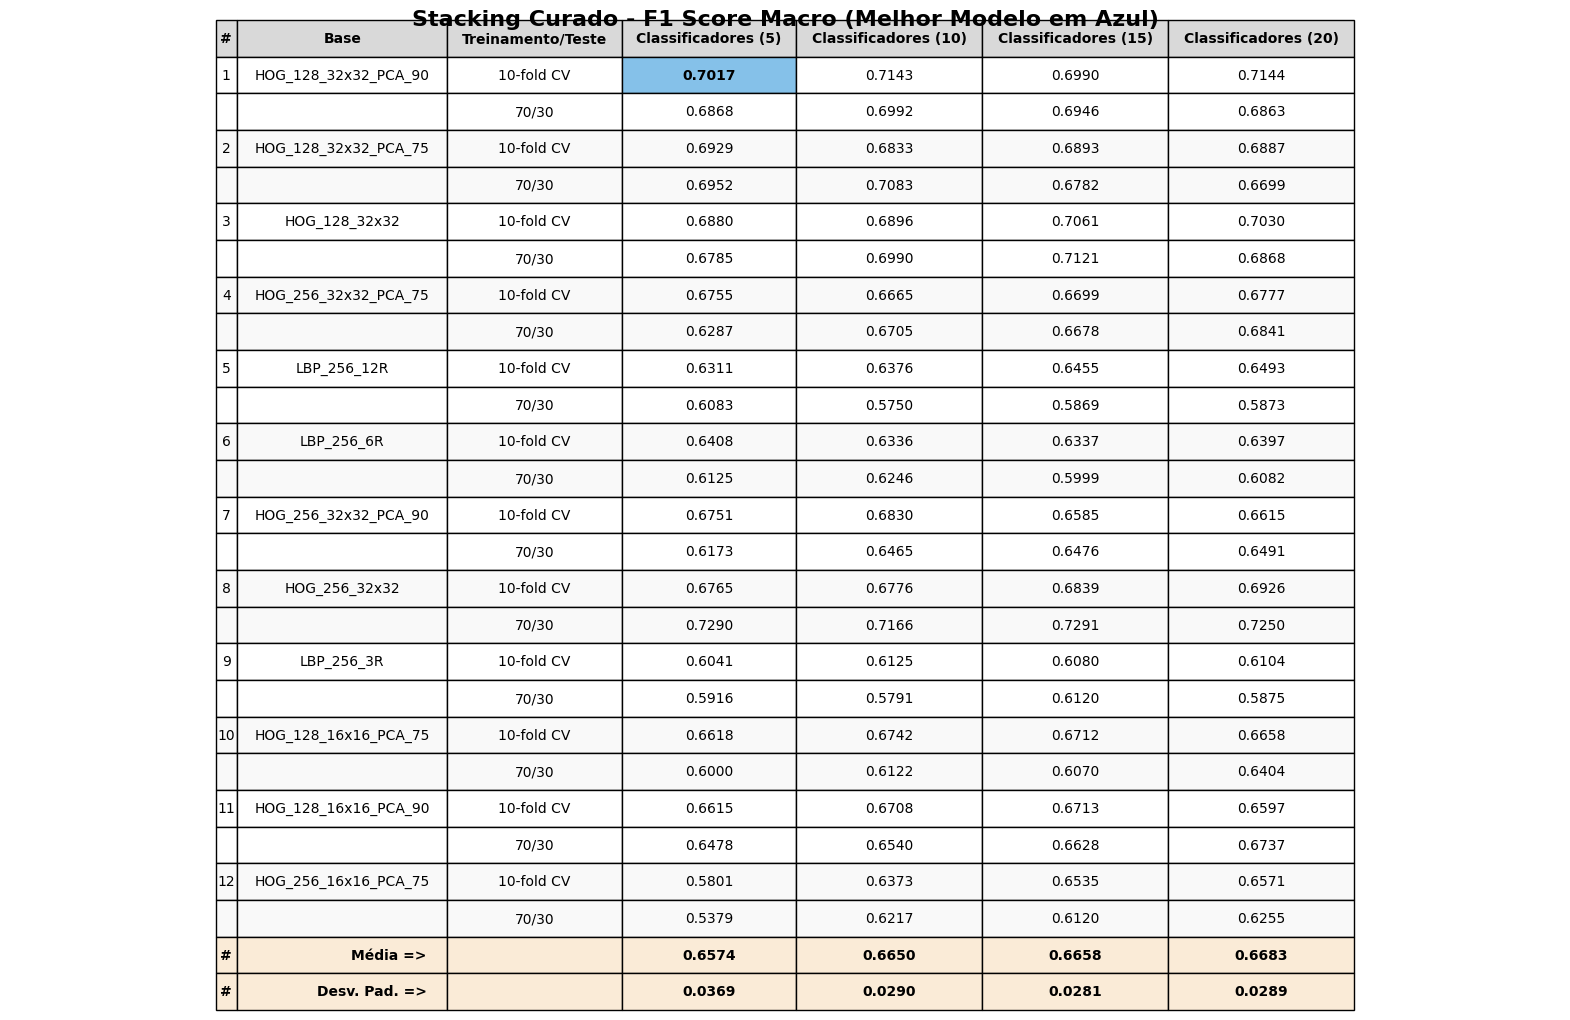

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from google.colab import drive
import warnings

# Importando os modelos
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')

# --- 1. Configuração Inicial ---
drive.mount('/content/drive')

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_top12 = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')
caminho_csv = os.path.join(caminho_drive, 'Resultados_Stacking_Estatistica.csv')
caminho_pdf = os.path.join(caminho_drive, 'Resultados_Stacking_SIGAA.pdf')
caminho_temp = os.path.join(caminho_drive, 'Resultados_Stacking_BKP_Seguranca.csv')

try:
    df_top12 = pd.read_csv(caminho_top12)
    bases_top12 = df_top12.iloc[:, 0].tolist()
    arquivos_bases = [f"{base}.csv" if not str(base).endswith('.csv') else base for base in bases_top12]
except Exception as e:
    print(f"Erro ao ler lista de bases: {e}.")
    arquivos_bases = []

# --- 2. Listas Curadas de Classificadores (Alta Diversidade) ---
def obter_comite_curado(tamanho):
    estimadores = [('nb', GaussianNB())] # 1 único Naive Bayes para todos

    if tamanho == 5:
        estimadores.extend([
            ('knn_1', KNeighborsClassifier(n_neighbors=3, metric='euclidean')),
            ('knn_2', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('dt_1', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, early_stopping=True, random_state=42))
        ])
    elif tamanho == 10:
        estimadores.extend([
            # 3 k-NNs
            ('knn_1', KNeighborsClassifier(n_neighbors=3, metric='euclidean')),
            ('knn_2', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('knn_3', KNeighborsClassifier(n_neighbors=7, metric='euclidean')),
            # 3 DTs
            ('dt_1', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('dt_2', DecisionTreeClassifier(max_depth=20, random_state=42)),
            ('dt_3', DecisionTreeClassifier(max_depth=None, min_samples_split=5, random_state=42)),
            # 3 MLPs
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(50,), max_iter=1500, early_stopping=True, random_state=42)),
            ('mlp_2', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1500, early_stopping=True, random_state=42)),
            ('mlp_3', MLPClassifier(hidden_layer_sizes=(50, 50), activation='tanh', max_iter=1500, early_stopping=True, random_state=42))
        ])
    elif tamanho == 15:
        estimadores.extend([
            # 5 k-NNs
            ('knn_1', KNeighborsClassifier(n_neighbors=3, metric='euclidean')),
            ('knn_2', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('knn_3', KNeighborsClassifier(n_neighbors=7, metric='euclidean')),
            ('knn_4', KNeighborsClassifier(n_neighbors=9, metric='manhattan')),
            ('knn_5', KNeighborsClassifier(n_neighbors=11, metric='euclidean')),
            # 5 DTs
            ('dt_1', DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('dt_2', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('dt_3', DecisionTreeClassifier(max_depth=20, random_state=42)),
            ('dt_4', DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, random_state=42)),
            ('dt_5', DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)),
            # 4 MLPs
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, early_stopping=True, random_state=42)),
            ('mlp_2', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, early_stopping=True, random_state=42)),
            ('mlp_3', MLPClassifier(hidden_layer_sizes=(50,), activation='tanh', max_iter=2000, early_stopping=True, random_state=42)),
            ('mlp_4', MLPClassifier(hidden_layer_sizes=(100,), solver='sgd', max_iter=2000, early_stopping=True, random_state=42))
        ])
    elif tamanho == 20:
        estimadores.extend([
            # 7 k-NNs
            ('knn_1', KNeighborsClassifier(n_neighbors=3)),
            ('knn_2', KNeighborsClassifier(n_neighbors=3, metric='manhattan')),
            ('knn_3', KNeighborsClassifier(n_neighbors=5)),
            ('knn_4', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('knn_5', KNeighborsClassifier(n_neighbors=7)),
            ('knn_6', KNeighborsClassifier(n_neighbors=9, metric='manhattan')),
            ('knn_7', KNeighborsClassifier(n_neighbors=11)),
            # 6 DTs
            ('dt_1', DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('dt_2', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('dt_3', DecisionTreeClassifier(max_depth=15, random_state=42)),
            ('dt_4', DecisionTreeClassifier(max_depth=20, random_state=42)),
            ('dt_5', DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, random_state=42)),
            ('dt_6', DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)),
            # 6 MLPs
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(100,), max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_2', MLPClassifier(hidden_layer_sizes=(150,), max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_3', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_4', MLPClassifier(hidden_layer_sizes=(50,), activation='tanh', max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_5', MLPClassifier(hidden_layer_sizes=(100,), solver='sgd', max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_6', MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2500, early_stopping=True, random_state=42))
        ])
    return estimadores

n_classifiers_list = [5, 10, 15, 20]
colunas_modelos = [f"Classificadores ({n})" for n in n_classifiers_list]
colunas_df = ['#', 'Base', 'Treinamento/Teste'] + colunas_modelos
resultados = []

# --- 3. Loop de Treinamento e Avaliação ---
for idx, arquivo in enumerate(arquivos_bases):
    arquivo_leitura = arquivo
    usar_pca = False
    n_comp_pca = None
    if "_PCA_" in arquivo:
        usar_pca = True
        partes = arquivo.replace('.csv', '').split('_PCA_')
        arquivo_leitura = partes[0] + '.csv'
        n_comp_pca = int(partes[1]) / 100.0

    caminho_arquivo = os.path.join(caminho_drive, arquivo_leitura)
    nome_base = arquivo.replace('.csv', '')
    print(f"Processando base {idx+1}/{len(arquivos_bases)}: {nome_base}")

    try:
        df = pd.read_csv(caminho_arquivo)
    except Exception as e:
        print(f"Erro ao ler base {arquivo_leitura}: {e}")
        continue

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    linha_cv = {'#': str(idx+1), 'Base': nome_base, 'Treinamento/Teste': '10-fold CV'}
    linha_holdout = {'#': '', 'Base': '', 'Treinamento/Teste': '70/30'}

    for n in n_classifiers_list:
        col_name = f"Classificadores ({n})"

        estimadores_base = obter_comite_curado(n)
        stacking = StackingClassifier(estimators=estimadores_base, n_jobs=-1)

        if usar_pca:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('pca', PCA(n_components=n_comp_pca, random_state=42)),
                ('stacking', stacking)
            ])
        else:
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('stacking', stacking)
            ])

        # 10-fold CV
        try:
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
            scores = cross_val_score(pipeline, X, y, cv=skf, scoring='f1_macro', n_jobs=-1)
            linha_cv[col_name] = round(scores.mean(), 4)
        except Exception as e:
            print(f"Erro CV {col_name}: {e}")
            linha_cv[col_name] = np.nan

        # Holdout 70/30
        try:
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            linha_holdout[col_name] = round(f1_score(y_test, y_pred, average='macro'), 4)
        except Exception as e:
            print(f"Erro Holdout {col_name}: {e}")
            linha_holdout[col_name] = np.nan

    resultados.append(linha_cv)
    resultados.append(linha_holdout)

    # Backup de Segurança a cada base!
    pd.DataFrame(resultados, columns=colunas_df).to_csv(caminho_temp, index=False)
    print(f"Progresso salvo em {caminho_temp}...")

if not resultados:
    print("Nenhum resultado gerado.")
    exit()

df_final = pd.DataFrame(resultados, columns=colunas_df)

# --- 4. Análise Estatística (Teste de Friedman) ---
print("\n" + "="*60)
print("ANÁLISE ESTATÍSTICA (10-fold CV) - STACKING CURADO")
print("="*60)

df_cv = df_final[df_final['Treinamento/Teste'] == '10-fold CV'].copy()
df_cv[colunas_modelos] = df_cv[colunas_modelos].apply(pd.to_numeric, errors='coerce')
df_cv_stats = df_cv[colunas_modelos].fillna(df_cv[colunas_modelos].mean())

dados_modelos = [df_cv_stats[col].values for col in colunas_modelos]
stat, p_value = friedmanchisquare(*dados_modelos)

medias_cv = df_cv_stats.mean().to_dict()
modelo_maior_media = max(medias_cv, key=medias_cv.get)
ordem_complexidade = colunas_modelos

print(f"Estatística de Friedman: {stat:.4f}")
print(f"Valor-p: {p_value:.4e}\n")

configuracao_vencedora = ""

if p_value < 0.05:
    print("CONCLUSÃO: Há diferença estatística (p < 0.05).")
    configuracao_vencedora = modelo_maior_media
    print(f"-> VENCEDOR: {configuracao_vencedora} (F1: {medias_cv[configuracao_vencedora]:.4f})")
else:
    print("CONCLUSÃO: NÃO há diferença estatística (p >= 0.05).")
    configuracao_vencedora = next((m for m in ordem_complexidade if m in colunas_modelos), None)
    print(f"-> VENCEDOR (Por Complexidade): {configuracao_vencedora}")
print("="*60 + "\n")

# --- 5. Identificando a Melhor Célula para Pintar de Azul ---
idx_melhor_base_vencedor = df_cv[configuracao_vencedora].idxmax()
base_do_melhor_modelo = df_cv.loc[idx_melhor_base_vencedor, 'Base']

# --- 6. Médias e Desvios Padrão para a Tabela ---
linha_media = {'#': '#', 'Base': 'Média =>', 'Treinamento/Teste': ''}
linha_desvio = {'#': '#', 'Base': 'Desv. Pad. =>', 'Treinamento/Teste': ''}

for col in colunas_modelos:
    linha_media[col] = f"{df_cv_stats[col].mean():.4f}"
    linha_desvio[col] = f"{df_cv_stats[col].std():.4f}"

df_final = pd.concat([df_final, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)

# Formatação
for col in colunas_modelos:
    df_final[col] = df_final[col].apply(lambda x: f"{float(x):.4f}" if pd.notna(x) and str(x).replace('.','').isdigit() else x)

df_final.fillna('', inplace=True)
df_final.to_csv(caminho_csv, index=False)
os.remove(caminho_temp) # Remove o backup temporário após salvar o final

# --- 7. Geração do PDF com Matplotlib ---
print("Gerando o PDF...")
fig, ax = plt.subplots(figsize=(20, 12))
ax.axis('tight')
ax.axis('off')

plt.title("Stacking Curado - F1 Score Macro (Melhor Modelo em Azul)", fontweight='bold', fontsize=16, pad=20)

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2.2)

total_linhas = len(df_final)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > total_linhas - 2:
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
        if col == 1: cell.set_text_props(ha='right')
    else:
        nome_coluna_atual = df_final.columns[col]

        base_atual = df_final.iloc[row-1]['Base']
        if not base_atual:
            base_atual = df_final.iloc[row-2]['Base']

        tipo_teste = df_final.iloc[row-1]['Treinamento/Teste']

        if nome_coluna_atual == configuracao_vencedora and base_atual == base_do_melhor_modelo and tipo_teste == '10-fold CV':
            cell.set_facecolor('#85c1e9')
            cell.set_text_props(weight='bold')
        else:
            base_row_index = (row - 1) // 2
            if base_row_index % 2 == 0:
                cell.set_facecolor('#ffffff')
            else:
                cell.set_facecolor('#f9f9f9')

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ Processo concluído! Tabela salva em: {caminho_pdf}")


#Voting

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Processando base 1/12: HOG_128_32x32_PCA_90
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Voting_Soft_BKP.csv...
Processando base 2/12: HOG_128_32x32_PCA_75
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Voting_Soft_BKP.csv...
Processando base 3/12: HOG_128_32x32
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Voting_Soft_BKP.csv...
Processando base 4/12: HOG_256_32x32_PCA_75
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Voting_Soft_BKP.csv...
Processando base 5/12: LBP_256_12R
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Voting_Soft_BKP.csv...
Processando base 6/12: LBP_256_6R
Progresso salvo em /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Voting_Soft_BKP.csv.

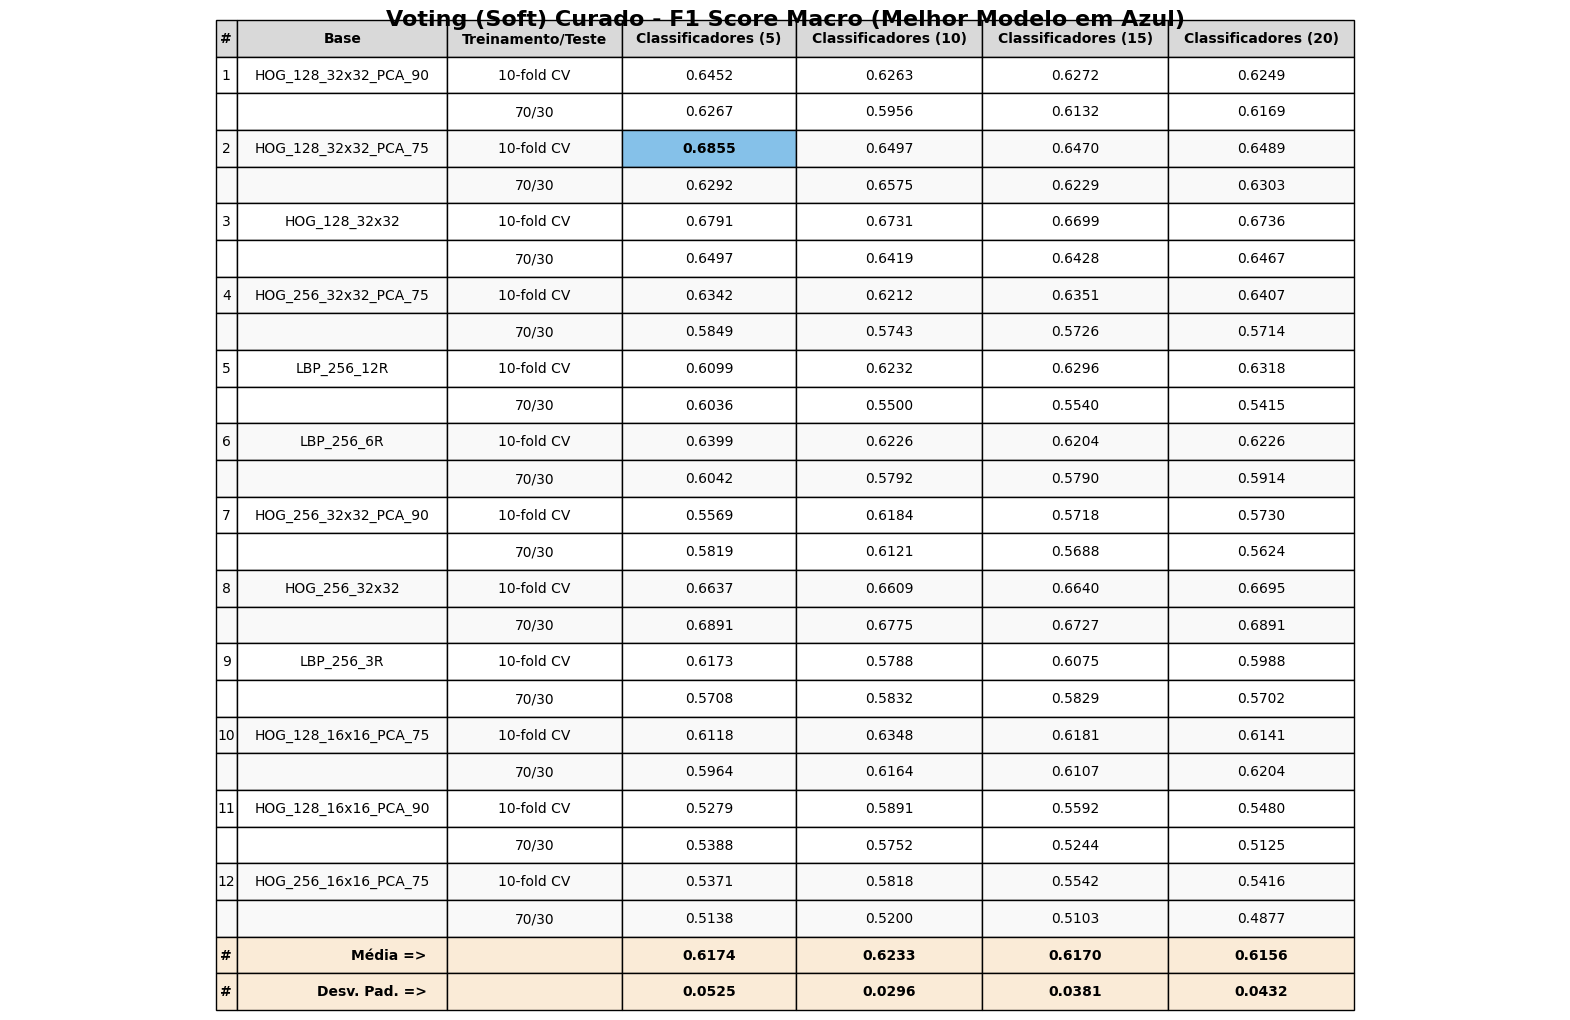

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from google.colab import drive
import warnings

# Importando os modelos e o Voting
from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')

# --- 1. Configuração Inicial ---
drive.mount('/content/drive')

caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'
caminho_top12 = os.path.join(caminho_drive, 'Top_12_Melhores_Bases.csv')
caminho_csv = os.path.join(caminho_drive, 'Resultados_Voting_Soft_Estatistica.csv')
caminho_pdf = os.path.join(caminho_drive, 'Resultados_Voting_Soft_SIGAA.pdf')
caminho_temp = os.path.join(caminho_drive, 'Resultados_Voting_Soft_BKP.csv')

try:
    df_top12 = pd.read_csv(caminho_top12)
    bases_top12 = df_top12.iloc[:, 0].tolist()
    arquivos_bases = [f"{base}.csv" if not str(base).endswith('.csv') else base for base in bases_top12]
except Exception as e:
    print(f"Erro ao ler lista de bases: {e}.")
    arquivos_bases = []

# --- 2. Listas Curadas de Classificadores (Alta Diversidade) ---
def obter_comite_curado(tamanho):
    estimadores = [('nb', GaussianNB())]

    if tamanho == 5:
        estimadores.extend([
            ('knn_1', KNeighborsClassifier(n_neighbors=3, metric='euclidean')),
            ('knn_2', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('dt_1', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, early_stopping=True, random_state=42))
        ])
    elif tamanho == 10:
        estimadores.extend([
            ('knn_1', KNeighborsClassifier(n_neighbors=3, metric='euclidean')),
            ('knn_2', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('knn_3', KNeighborsClassifier(n_neighbors=7, metric='euclidean')),
            ('dt_1', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('dt_2', DecisionTreeClassifier(max_depth=20, random_state=42)),
            ('dt_3', DecisionTreeClassifier(max_depth=None, min_samples_split=5, random_state=42)),
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(50,), max_iter=1500, early_stopping=True, random_state=42)),
            ('mlp_2', MLPClassifier(hidden_layer_sizes=(100,), max_iter=1500, early_stopping=True, random_state=42)),
            ('mlp_3', MLPClassifier(hidden_layer_sizes=(50, 50), activation='tanh', max_iter=1500, early_stopping=True, random_state=42))
        ])
    elif tamanho == 15:
        estimadores.extend([
            ('knn_1', KNeighborsClassifier(n_neighbors=3, metric='euclidean')),
            ('knn_2', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('knn_3', KNeighborsClassifier(n_neighbors=7, metric='euclidean')),
            ('knn_4', KNeighborsClassifier(n_neighbors=9, metric='manhattan')),
            ('knn_5', KNeighborsClassifier(n_neighbors=11, metric='euclidean')),
            ('dt_1', DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('dt_2', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('dt_3', DecisionTreeClassifier(max_depth=20, random_state=42)),
            ('dt_4', DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, random_state=42)),
            ('dt_5', DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)),
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, early_stopping=True, random_state=42)),
            ('mlp_2', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, early_stopping=True, random_state=42)),
            ('mlp_3', MLPClassifier(hidden_layer_sizes=(50,), activation='tanh', max_iter=2000, early_stopping=True, random_state=42)),
            ('mlp_4', MLPClassifier(hidden_layer_sizes=(100,), solver='sgd', max_iter=2000, early_stopping=True, random_state=42))
        ])
    elif tamanho == 20:
        estimadores.extend([
            ('knn_1', KNeighborsClassifier(n_neighbors=3)),
            ('knn_2', KNeighborsClassifier(n_neighbors=3, metric='manhattan')),
            ('knn_3', KNeighborsClassifier(n_neighbors=5)),
            ('knn_4', KNeighborsClassifier(n_neighbors=5, metric='manhattan')),
            ('knn_5', KNeighborsClassifier(n_neighbors=7)),
            ('knn_6', KNeighborsClassifier(n_neighbors=9, metric='manhattan')),
            ('knn_7', KNeighborsClassifier(n_neighbors=11)),
            ('dt_1', DecisionTreeClassifier(max_depth=5, random_state=42)),
            ('dt_2', DecisionTreeClassifier(max_depth=10, random_state=42)),
            ('dt_3', DecisionTreeClassifier(max_depth=15, random_state=42)),
            ('dt_4', DecisionTreeClassifier(max_depth=20, random_state=42)),
            ('dt_5', DecisionTreeClassifier(max_depth=None, min_samples_leaf=2, random_state=42)),
            ('dt_6', DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)),
            ('mlp_1', MLPClassifier(hidden_layer_sizes=(100,), max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_2', MLPClassifier(hidden_layer_sizes=(150,), max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_3', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_4', MLPClassifier(hidden_layer_sizes=(50,), activation='tanh', max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_5', MLPClassifier(hidden_layer_sizes=(100,), solver='sgd', max_iter=2500, early_stopping=True, random_state=42)),
            ('mlp_6', MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2500, early_stopping=True, random_state=42))
        ])
    return estimadores

n_classifiers_list = [5, 10, 15, 20]
colunas_modelos = [f"Classificadores ({n})" for n in n_classifiers_list]
colunas_df = ['#', 'Base', 'Treinamento/Teste'] + colunas_modelos
resultados = []

# --- 3. Loop de Treinamento e Avaliação ---
for idx, arquivo in enumerate(arquivos_bases):
    caminho_arquivo = os.path.join(caminho_drive, arquivo)
    nome_base = arquivo.replace('.csv', '')
    print(f"Processando base {idx+1}/{len(arquivos_bases)}: {nome_base}")

    try:
        df = pd.read_csv(caminho_arquivo)
    except Exception as e:
        print(f"Erro ao ler base {arquivo}: {e}")
        continue

    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

    linha_cv = {'#': str(idx+1), 'Base': nome_base, 'Treinamento/Teste': '10-fold CV'}
    linha_holdout = {'#': '', 'Base': '', 'Treinamento/Teste': '70/30'}

    for n in n_classifiers_list:
        col_name = f"Classificadores ({n})"

        estimadores_base = obter_comite_curado(n)

        # ---------------------------------------------------------
        # ALTERAÇÃO AQUI: voting='soft' para usar as probabilidades
        # ---------------------------------------------------------
        voting = VotingClassifier(estimators=estimadores_base, voting='soft', n_jobs=-1)

        # 10-fold CV
        try:
            skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
            scores = cross_val_score(voting, X_scaled, y, cv=skf, scoring='f1_macro', n_jobs=-1)
            linha_cv[col_name] = round(scores.mean(), 4)
        except Exception as e:
            print(f"Erro CV {col_name}: {e}")
            linha_cv[col_name] = np.nan

        # Holdout 70/30
        try:
            voting.fit(X_train, y_train)
            y_pred = voting.predict(X_test)
            linha_holdout[col_name] = round(f1_score(y_test, y_pred, average='macro'), 4)
        except Exception as e:
            print(f"Erro Holdout {col_name}: {e}")
            linha_holdout[col_name] = np.nan

    resultados.append(linha_cv)
    resultados.append(linha_holdout)

    # Backup de Segurança
    pd.DataFrame(resultados, columns=colunas_df).to_csv(caminho_temp, index=False)
    print(f"Progresso salvo em {caminho_temp}...")

if not resultados:
    print("Nenhum resultado gerado.")
    exit()

df_final = pd.DataFrame(resultados, columns=colunas_df)

# --- 4. Análise Estatística (Teste de Friedman) ---
print("\n" + "="*60)
print("ANÁLISE ESTATÍSTICA (10-fold CV) - VOTING (SOFT)")
print("="*60)

df_cv = df_final[df_final['Treinamento/Teste'] == '10-fold CV'].copy()
df_cv[colunas_modelos] = df_cv[colunas_modelos].apply(pd.to_numeric, errors='coerce')
df_cv_stats = df_cv[colunas_modelos].fillna(df_cv[colunas_modelos].mean())

dados_modelos = [df_cv_stats[col].values for col in colunas_modelos]
stat, p_value = friedmanchisquare(*dados_modelos)

medias_cv = df_cv_stats.mean().to_dict()
modelo_maior_media = max(medias_cv, key=medias_cv.get)
ordem_complexidade = colunas_modelos

print(f"Estatística de Friedman: {stat:.4f}")
print(f"Valor-p: {p_value:.4e}\n")

configuracao_vencedora = ""

if p_value < 0.05:
    print("CONCLUSÃO: Há diferença estatística (p < 0.05).")
    configuracao_vencedora = modelo_maior_media
    print(f"-> VENCEDOR: {configuracao_vencedora} (F1: {medias_cv[configuracao_vencedora]:.4f})")
else:
    print("CONCLUSÃO: NÃO há diferença estatística (p >= 0.05).")
    configuracao_vencedora = next((m for m in ordem_complexidade if m in colunas_modelos), None)
    print(f"-> VENCEDOR (Por Complexidade): {configuracao_vencedora}")
print("="*60 + "\n")

# --- 5. Identificando a Melhor Célula para Pintar de Azul ---
idx_melhor_base_vencedor = df_cv[configuracao_vencedora].idxmax()
base_do_melhor_modelo = df_cv.loc[idx_melhor_base_vencedor, 'Base']

# --- 6. Médias e Desvios Padrão para a Tabela ---
linha_media = {'#': '#', 'Base': 'Média =>', 'Treinamento/Teste': ''}
linha_desvio = {'#': '#', 'Base': 'Desv. Pad. =>', 'Treinamento/Teste': ''}

for col in colunas_modelos:
    linha_media[col] = f"{df_cv_stats[col].mean():.4f}"
    linha_desvio[col] = f"{df_cv_stats[col].std():.4f}"

df_final = pd.concat([df_final, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)

for col in colunas_modelos:
    df_final[col] = df_final[col].apply(lambda x: f"{float(x):.4f}" if pd.notna(x) and str(x).replace('.','').isdigit() else x)

df_final.fillna('', inplace=True)
df_final.to_csv(caminho_csv, index=False)
os.remove(caminho_temp)

# --- 7. Geração do PDF com Matplotlib ---
print("Gerando o PDF...")
fig, ax = plt.subplots(figsize=(20, 12))
ax.axis('tight')
ax.axis('off')

plt.title("Voting (Soft) Curado - F1 Score Macro (Melhor Modelo em Azul)", fontweight='bold', fontsize=16, pad=20)

tabela = ax.table(cellText=df_final.values,
                  colLabels=df_final.columns,
                  loc='center',
                  cellLoc='center')

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
tabela.scale(1, 2.2)

total_linhas = len(df_final)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row > total_linhas - 2:
        cell.set_facecolor('#faebd7')
        cell.set_text_props(weight='bold')
        if col == 1: cell.set_text_props(ha='right')
    else:
        nome_coluna_atual = df_final.columns[col]
        base_atual = df_final.iloc[row-1]['Base']
        if not base_atual:
            base_atual = df_final.iloc[row-2]['Base']

        tipo_teste = df_final.iloc[row-1]['Treinamento/Teste']

        if nome_coluna_atual == configuracao_vencedora and base_atual == base_do_melhor_modelo and tipo_teste == '10-fold CV':
            cell.set_facecolor('#85c1e9')
            cell.set_text_props(weight='bold')
        else:
            base_row_index = (row - 1) // 2
            if base_row_index % 2 == 0:
                cell.set_facecolor('#ffffff')
            else:
                cell.set_facecolor('#f9f9f9')

plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
print(f"✅ Processo concluído! Tabela salva em: {caminho_pdf}")

# TABELAS COMITES

In [ ]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import friedmanchisquare
from google.colab import drive
import warnings

warnings.filterwarnings('ignore')

# --- 1. Configuração Inicial ---
drive.mount('/content/drive')
caminho_drive = '/content/drive/My Drive/aprendizadoDeMaquina/content/'

# Caminhos dos CSVs existentes
csvs = {
    'Bagging': os.path.join(caminho_drive, 'Resultados_Bagging_Estatistica.csv'),
    'Random Forest': os.path.join(caminho_drive, 'Resultados_RF_Estatistica.csv'),
    'Stacking': os.path.join(caminho_drive, 'Resultados_Stacking_Estatistica.csv'),
    'Voting': os.path.join(caminho_drive, 'Resultados_Voting_Soft_Estatistica.csv'),
}

# Caminhos de saída dos PDFs regenerados
pdfs = {
    'Bagging': os.path.join(caminho_drive, 'Resultados_Bagging_SIGAA_Final.pdf'),
    'Random Forest': os.path.join(caminho_drive, 'Resultados_RF_SIGAA_Final.pdf'),
    'Stacking': os.path.join(caminho_drive, 'Resultados_Stacking_SIGAA_Final.pdf'),
    'Voting': os.path.join(caminho_drive, 'Resultados_Voting_SIGAA_Final.pdf'),
}

# Ordens de complexidade (do mais simples ao mais complexo)
ordens_complexidade = {
    'Bagging': [
        'NB (10)', 'NB (15)', 'NB (20)',
        'DT (10)', 'DT (15)', 'DT (20)',
        'k-NN (10)', 'k-NN (15)', 'k-NN (20)',
        'MLP (10)', 'MLP (15)', 'MLP (20)'
    ],
    'Random Forest': [
        'Gini (10)', 'Entropy (10)',
        'Gini (20)', 'Entropy (20)',
        'Gini (30)', 'Entropy (30)',
        'Gini (100)', 'Entropy (100)'
    ],
    'Stacking': [
        'Classificadores (5)', 'Classificadores (10)',
        'Classificadores (15)', 'Classificadores (20)'
    ],
    'Voting': [
        'Classificadores (5)', 'Classificadores (10)',
        'Classificadores (15)', 'Classificadores (20)'
    ],
}

# =====================================================================
# FUNÇÃO: Análise estatística + seleção do vencedor
# =====================================================================
def analisar_e_selecionar_vencedor(df_csv, colunas_modelos, ordem_complexidade, nome_comite):
    """
    Aplica o Teste de Friedman nos resultados de 10-fold CV.
    - Se p < 0.05: escolhe o modelo com MAIOR média (melhor desempenho).
    - Se p >= 0.05: escolhe o modelo MAIS SIMPLES (menor complexidade).
    Retorna: (configuracao_vencedora, stat, p_value, medias_cv_dict, motivo)
    """
    # Filtra apenas as linhas de 10-fold CV
    df_cv = df_csv[df_csv['Treinamento/Teste'] == '10-fold CV'].copy()
    df_cv[colunas_modelos] = df_cv[colunas_modelos].apply(pd.to_numeric, errors='coerce')
    df_cv_stats = df_cv[colunas_modelos].fillna(df_cv[colunas_modelos].mean())

    # Teste de Friedman
    dados_modelos = [df_cv_stats[col].values for col in colunas_modelos]
    stat, p_value = friedmanchisquare(*dados_modelos)

    medias_cv = df_cv_stats.mean().to_dict()
    modelo_maior_media = max(medias_cv, key=medias_cv.get)

    print(f"\n{'='*60}")
    print(f"ANÁLISE ESTATÍSTICA - {nome_comite.upper()}")
    print(f"{'='*60}")
    print(f"Estatística de Friedman: {stat:.4f}")
    print(f"Valor-p: {p_value:.4e}\n")

    if p_value < 0.05:
        configuracao_vencedora = modelo_maior_media
        motivo = 'Melhor Média (p < 0.05)'
        print(f"CONCLUSÃO: Há diferença estatística significativa (p < 0.05).")
        print(f"Decisão: Escolhemos o modelo com o melhor desempenho médio.")
        print(f"-> VENCEDOR: {configuracao_vencedora} (F1 Média: {medias_cv[configuracao_vencedora]:.4f})")
    else:
        # Sem diferença estatística: escolher o mais simples
        configuracao_vencedora = ordem_complexidade[0]  # O primeiro da lista é o mais simples
        motivo = 'Mais Simples (p >= 0.05)'
        print(f"CONCLUSÃO: NÃO há diferença estatística significativa (p >= 0.05).")
        print(f"Decisão: Como não há diferença, escolhemos o modelo mais simples.")
        print(f"-> VENCEDOR (Por Complexidade): {configuracao_vencedora} (F1 Média: {medias_cv[configuracao_vencedora]:.4f})")

    print(f"\nMédias de todos os modelos:")
    for modelo, media in sorted(medias_cv.items(), key=lambda x: x[1], reverse=True):
        marcador = " <-- VENCEDOR" if modelo == configuracao_vencedora else ""
        print(f"  {modelo}: {media:.4f}{marcador}")
    print(f"{'='*60}")

    return configuracao_vencedora, stat, p_value, medias_cv, motivo, df_cv_stats


# =====================================================================
# FUNÇÃO: Gerar PDF da tabela com destaque correto
# =====================================================================
def gerar_pdf_tabela(df_csv, colunas_modelos, configuracao_vencedora, nome_comite, caminho_pdf, stat, p_value, motivo):
    """
    Gera o PDF da tabela, destacando em AZUL a LINHA INTEIRA da melhor base
    para a configuração vencedora (apenas no 10-fold CV).
    O título fica ACIMA da tabela sem sobrepor.
    """
    # Recriar as linhas de Média e Desvio Padrão limpas
    df_cv = df_csv[df_csv['Treinamento/Teste'] == '10-fold CV'].copy()
    df_cv[colunas_modelos] = df_cv[colunas_modelos].apply(pd.to_numeric, errors='coerce')
    df_cv_stats = df_cv[colunas_modelos].fillna(df_cv[colunas_modelos].mean())

    # Encontrar a melhor base para a configuração vencedora
    idx_melhor = df_cv[configuracao_vencedora].astype(float).idxmax()
    base_do_melhor_modelo = df_cv.loc[idx_melhor, 'Base']
    melhor_f1 = float(df_cv.loc[idx_melhor, configuracao_vencedora])

    # Reconstruir df_final com Média e Desvio Padrão
    # Primeiro, pegar as linhas de dados (sem média/desvio que possam estar no CSV)
    df_dados = df_csv[~df_csv['Base'].isin(['Média =>', 'MÉDIA =>', 'Desv. Pad. =>', 'DESV. PAD. =>'])].copy()

    # Montar linhas de média e desvio
    primeira_col = df_dados.columns[0]
    segunda_col = df_dados.columns[1]
    terceira_col = df_dados.columns[2]

    linha_media = {primeira_col: '#', segunda_col: 'Média =>', terceira_col: ''}
    linha_desvio = {primeira_col: '#', segunda_col: 'Desv. Pad. =>', terceira_col: ''}

    for col in colunas_modelos:
        linha_media[col] = f"{df_cv_stats[col].mean():.4f}"
        linha_desvio[col] = f"{df_cv_stats[col].std():.4f}"

    df_final = pd.concat([df_dados, pd.DataFrame([linha_media, linha_desvio])], ignore_index=True)

    # Formatar valores numéricos como strings com 4 casas
    for col in colunas_modelos:
        df_final[col] = df_final[col].apply(
            lambda x: f"{float(x):.4f}" if pd.notna(x) and str(x).replace('.','',1).replace('-','',1).isdigit() else x
        )
    df_final.fillna('', inplace=True)

    # --- Geração do PDF ---
    fig, ax = plt.subplots(figsize=(28, 16))
    ax.axis('tight')
    ax.axis('off')

    # TÍTULO: usando fig.suptitle para garantir que fique acima da tabela sem sobrepor
    fig.suptitle(
        f"{nome_comite} - F1 Score Macro\n"
        f"Vencedor: {configuracao_vencedora} ({motivo}) | "
        f"Friedman p={p_value:.4e}",
        fontweight='bold', fontsize=14, y=0.98
    )

    tabela = ax.table(
        cellText=df_final.values,
        colLabels=df_final.columns,
        loc='center',
        cellLoc='center'
    )

    tabela.auto_set_font_size(False)
    tabela.set_fontsize(8)
    tabela.auto_set_column_width(col=list(range(len(df_final.columns))))
    tabela.scale(1, 2)

    total_linhas = len(df_final)

    for (row, col), cell in tabela.get_celld().items():
        if row == 0:
            # Cabeçalho
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#d9d9d9')
        elif row > total_linhas - 2:
            # Linhas de Média e Desvio Padrão
            cell.set_facecolor('#faebd7')
            cell.set_text_props(weight='bold')
            if col == 1:
                cell.set_text_props(ha='right')
        else:
            # Lógica para pegar o nome da base atual (para linhas de holdout o nome fica vazio)
            base_atual = df_final.iloc[row - 1][segunda_col]
            if not base_atual:
                base_atual = df_final.iloc[row - 2][segunda_col]

            tipo_teste = df_final.iloc[row - 1][terceira_col]
            nome_coluna_atual = df_final.columns[col]

            # Destaque azul: célula exata = configuração vencedora + melhor base + 10-fold CV
            if (nome_coluna_atual == configuracao_vencedora and
                base_atual == base_do_melhor_modelo and
                tipo_teste == '10-fold CV'):
                cell.set_facecolor('#85c1e9')  # Azul forte
                cell.set_text_props(weight='bold')
            else:
                # Zebrado normal
                base_row_index = (row - 1) // 2
                if base_row_index % 2 == 0:
                    cell.set_facecolor('#ffffff')
                else:
                    cell.set_facecolor('#f9f9f9')

    plt.savefig(caminho_pdf, format='pdf', bbox_inches='tight', dpi=300)
    plt.close()

    print(f"\n✅ PDF gerado: {caminho_pdf}")
    print(f"   Célula destacada: {configuracao_vencedora} na base {base_do_melhor_modelo} (F1={melhor_f1:.4f})")

    return configuracao_vencedora, base_do_melhor_modelo, melhor_f1


# =====================================================================
# --- 2. PROCESSAR CADA COMITÊ ---
# =====================================================================
vencedores = {}  # Armazena {nome_comite: (config_vencedora, media_cv)}

for nome_comite in ['Bagging', 'Random Forest', 'Stacking', 'Voting']:
    print(f"\n\n{'#'*70}")
    print(f"# PROCESSANDO: {nome_comite.upper()}")
    print(f"{'#'*70}")

    csv_path = csvs[nome_comite]

    if not os.path.exists(csv_path):
        print(f"⚠️ CSV não encontrado: {csv_path}. Pulando.")
        continue

    df_csv = pd.read_csv(csv_path)
    df_csv.fillna('', inplace=True)

    # Identificar colunas de modelos (tudo a partir da 4ª coluna)
    colunas_modelos = [c for c in df_csv.columns if c not in ['#', 'Base', 'Treinamento/Teste']]

    # Filtrar apenas colunas que existem na ordem de complexidade
    ordem = ordens_complexidade[nome_comite]
    ordem_filtrada = [m for m in ordem if m in colunas_modelos]

    # Análise estatística
    config_vencedora, stat, p_value, medias_cv, motivo, df_cv_stats = analisar_e_selecionar_vencedor(
        df_csv, colunas_modelos, ordem_filtrada, nome_comite
    )

    # Gerar PDF
    config_v, base_v, f1_v = gerar_pdf_tabela(
        df_csv, colunas_modelos, config_vencedora, nome_comite,
        pdfs[nome_comite], stat, p_value, motivo
    )

    # Guardar vencedor para a análise final
    vencedores[nome_comite] = {
        'config': config_vencedora,
        'media_cv': medias_cv[config_vencedora],
        'motivo': motivo,
        'melhor_base': base_v,
        'melhor_f1': f1_v,
        'medias_por_base': df_cv_stats[config_vencedora].values if config_vencedora in df_cv_stats.columns else []
    }


# =====================================================================
# --- 3. ANÁLISE FINAL: COMPARAÇÃO DOS 4 VENCEDORES ---
# =====================================================================
print(f"\n\n{'#'*70}")
print(f"# ANÁLISE FINAL: COMPARAÇÃO DOS MELHORES DE CADA COMITÊ")
print(f"{'#'*70}")

print("\nVencedores de cada comitê:")
for nome, info in vencedores.items():
    print(f"  {nome}: {info['config']} (F1 Média CV: {info['media_cv']:.4f}) - {info['motivo']}")

# Para o Friedman final, precisamos dos scores de cada vencedor em cada base
# Vamos extrair os valores de 10-fold CV de cada vencedor em cada base
dados_finais = {}
nomes_comites_ok = []

for nome_comite in ['Bagging', 'Random Forest', 'Stacking', 'Voting']:
    if nome_comite not in vencedores:
        continue

    csv_path = csvs[nome_comite]
    df_csv = pd.read_csv(csv_path)
    df_csv.fillna('', inplace=True)

    config = vencedores[nome_comite]['config']

    df_cv = df_csv[df_csv['Treinamento/Teste'] == '10-fold CV'].copy()
    # Remover linhas de média/desvio
    df_cv = df_cv[~df_cv['Base'].isin(['Média =>', 'MÉDIA =>', 'Desv. Pad. =>', 'DESV. PAD. =>'])]

    valores = pd.to_numeric(df_cv[config], errors='coerce').values
    dados_finais[nome_comite] = valores
    nomes_comites_ok.append(nome_comite)

# Teste de Friedman entre os 4 vencedores
print(f"\n{'='*60}")
print("TESTE DE FRIEDMAN ENTRE OS 4 VENCEDORES")
print(f"{'='*60}")

# Ordem de complexidade entre os comitês (do mais simples ao mais complexo)
ordem_complexidade_comites = ['Bagging', 'Random Forest', 'Voting', 'Stacking']

arrays = [dados_finais[n] for n in nomes_comites_ok]
min_len = min(len(a) for a in arrays)
arrays = [a[:min_len] for a in arrays]  # Garantir tamanhos iguais

stat_final, p_final = friedmanchisquare(*arrays)
print(f"Estatística de Friedman: {stat_final:.4f}")
print(f"Valor-p: {p_final:.4e}\n")

medias_finais = {n: np.nanmean(dados_finais[n]) for n in nomes_comites_ok}
melhor_comite_media = max(medias_finais, key=medias_finais.get)

if p_final < 0.05:
    vencedor_final = melhor_comite_media
    motivo_final = 'Melhor Média (p < 0.05)'
    print(f"CONCLUSÃO: Há diferença estatística significativa (p < 0.05).")
    print(f"Decisão: Escolhemos o comitê com melhor desempenho médio.")
else:
    # Sem diferença → mais simples
    vencedor_final = next((c for c in ordem_complexidade_comites if c in nomes_comites_ok), nomes_comites_ok[0])
    motivo_final = 'Mais Simples (p >= 0.05)'
    print(f"CONCLUSÃO: NÃO há diferença estatística significativa (p >= 0.05).")
    print(f"Decisão: Como não há diferença, escolhemos o comitê mais simples.")

print(f"\n-> VENCEDOR FINAL: {vencedor_final} - {vencedores[vencedor_final]['config']}")
print(f"   F1 Média CV: {medias_finais[vencedor_final]:.4f}")
print(f"   Motivo: {motivo_final}")

print(f"\nRanking completo:")
for i, (nome, media) in enumerate(sorted(medias_finais.items(), key=lambda x: x[1], reverse=True), 1):
    config_info = vencedores[nome]['config']
    marcador = " <-- VENCEDOR FINAL" if nome == vencedor_final else ""
    print(f"  {i}º {nome} ({config_info}): F1 Média = {media:.4f}{marcador}")

# --- Gerar tabela PDF da comparação final ---
caminho_pdf_final = os.path.join(caminho_drive, 'Resultados_Comparacao_Final_Comites.pdf')

# Montar DataFrame da comparação
linhas_comparacao = []
for nome_comite in nomes_comites_ok:
    info = vencedores[nome_comite]
    linhas_comparacao.append({
        'Comitê': nome_comite,
        'Configuração Vencedora': info['config'],
        'F1 Média CV': f"{info['media_cv']:.4f}",
        'Melhor Base': info['melhor_base'],
        'F1 Melhor Base': f"{info['melhor_f1']:.4f}",
        'Critério de Seleção': info['motivo']
    })

# Linha do vencedor final
linhas_comparacao.append({
    'Comitê': '>>> VENCEDOR FINAL',
    'Configuração Vencedora': f"{vencedor_final} - {vencedores[vencedor_final]['config']}",
    'F1 Média CV': f"{medias_finais[vencedor_final]:.4f}",
    'Melhor Base': vencedores[vencedor_final]['melhor_base'],
    'F1 Melhor Base': f"{vencedores[vencedor_final]['melhor_f1']:.4f}",
    'Critério de Seleção': motivo_final
})

df_comparacao = pd.DataFrame(linhas_comparacao)

fig, ax = plt.subplots(figsize=(22, 6))
ax.axis('tight')
ax.axis('off')

fig.suptitle(
    f"Comparação Final dos Comitês - Melhores Modelos\n"
    f"Friedman p={p_final:.4e} | Vencedor: {vencedor_final} ({motivo_final})",
    fontweight='bold', fontsize=14, y=0.95
)

tabela = ax.table(
    cellText=df_comparacao.values,
    colLabels=df_comparacao.columns,
    loc='center',
    cellLoc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.auto_set_column_width(col=list(range(len(df_comparacao.columns))))
tabela.scale(1, 2.5)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#d9d9d9')
    elif row == len(df_comparacao):  # Última linha = vencedor final
        cell.set_facecolor('#85c1e9')
        cell.set_text_props(weight='bold')
    else:
        comite_nome = df_comparacao.iloc[row - 1]['Comitê']
        if comite_nome == vencedor_final:
            cell.set_facecolor('#d4e6f1')  # Azul claro para o vencedor
        else:
            cell.set_facecolor('#ffffff' if row % 2 == 1 else '#f9f9f9')

plt.savefig(caminho_pdf_final, format='pdf', bbox_inches='tight', dpi=300)
plt.close()

print(f"\n✅ PDF da comparação final gerado: {caminho_pdf_final}")
print(f"\n{'='*60}")
print("PROCESSO COMPLETO! Todos os PDFs foram regenerados.")
print(f"{'='*60}")


Mounted at /content/drive


######################################################################
# PROCESSANDO: BAGGING
######################################################################

ANÁLISE ESTATÍSTICA - BAGGING
Estatística de Friedman: 87.6150
Valor-p: 4.8823e-14

CONCLUSÃO: Há diferença estatística significativa (p < 0.05).
Decisão: Escolhemos o modelo com o melhor desempenho médio.
-> VENCEDOR: MLP (10) (F1 Média: 0.6821)

Médias de todos os modelos:
  MLP (10): 0.6821 <-- VENCEDOR
  MLP (20): 0.6797
  MLP (15): 0.6783
  DT (20): 0.6337
  DT (15): 0.6304
  DT (10): 0.6184
  NB (15): 0.6042
  NB (20): 0.6039
  NB (10): 0.6037
  k-NN (10): 0.5665
  k-NN (15): 0.5653
  k-NN (20): 0.5646

✅ PDF gerado: /content/drive/My Drive/aprendizadoDeMaquina/content/Resultados_Bagging_SIGAA_Final.pdf
   Célula destacada: MLP (10) na base HOG_128_32x32_PCA_90 (F1=0.7221)


######################################################################
# PROCESSANDO: RANDOM FOREST
################